In [1]:
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm


In [2]:
def normalize_vsa_rows(v, eps=1e-12):
    """Normalize one VSA vector or a batch of VSA vectors to unit L2 norm."""
    squeeze = v.dim() == 1
    v = v.unsqueeze(0) if squeeze else v
    norms = torch.linalg.norm(v, dim=1, keepdim=True).clamp_min(eps)
    out = v / norms
    return out.squeeze(0) if squeeze else out


def make_unitary(v):
    """
    Makes input unitary (Fourier components have magnitude of 1).
    Used by the real HRR backend.
    """
    fv = torch.fft.fft(v.double(), dim=1)
    fv = fv / torch.sqrt(fv.real**2 + fv.imag**2).clamp_min(1e-12)
    return torch.fft.ifft(fv, dim=1).real.type_as(v)


def make_tensor_unitary(v):
    """
    Makes input tensor unitary (Fourier components have magnitude of 1).
    Used by the real HRR backend.
    """
    fv = torch.fft.fft(v, dim=1)
    fv = fv / torch.sqrt(fv.real**2 + fv.imag**2).clamp_min(1e-12)
    return torch.fft.ifft(fv, dim=1).real


def invert(a, dim):
    """HRR inverse under circular convolution."""
    return a[:, -torch.arange(dim, device=a.device)]


def identity(dim, *, representation="hrr", device=None, dtype=None):
    """Return the identity vector for the selected VSA backend."""
    device = torch.device("cpu") if device is None else torch.device(device)
    if representation == "fhrr":
        dtype = torch.complex128 if dtype is None else dtype
        return torch.ones((1, dim), dtype=dtype, device=device) / math.sqrt(dim)
    dtype = torch.float32 if dtype is None else dtype
    s = torch.zeros((1, dim), dtype=dtype, device=device)
    s[0, 0] = 1
    return s


def null(shape, *, device=None, dtype=torch.float32):
    """Return a null vector or batch of null vectors."""
    device = torch.device("cpu") if device is None else torch.device(device)
    return torch.zeros(shape, dtype=dtype, device=device)


def bind_hrr(a, b):
    """Real/complex HRR circular convolution binding using FFTs."""
    a = a.unsqueeze(0) if a.dim() == 1 else a
    b = b.unsqueeze(0) if b.dim() == 1 else b
    return torch.fft.ifft(torch.fft.fft(a, dim=1) * torch.fft.fft(b, dim=1), dim=1)


def bind_fhrr(a, b):
    """FHRR binding: elementwise complex multiplication with unit-norm phasor output."""
    a = a.unsqueeze(0) if a.dim() == 1 else a
    b = b.unsqueeze(0) if b.dim() == 1 else b
    return normalize_vsa_rows(a.to(torch.complex128) * b.to(torch.complex128))


def bind(a, b, representation="hrr"):
    """Bind two vectors using the selected VSA backend."""
    if representation == "fhrr":
        return bind_fhrr(a, b)
    if representation == "hrr":
        return bind_hrr(a, b)
    raise ValueError(f"Unknown VSA representation: {representation}")


def invert_vsa(a, dim, representation="hrr"):
    """Representation-specific inverse used for unbinding."""
    a = a.unsqueeze(0) if a.dim() == 1 else a
    if representation == "fhrr":
        return a.conj()
    if representation == "hrr":
        return invert(a, dim)
    raise ValueError(f"Unknown VSA representation: {representation}")


def SampleUniformHypersphere(surface, n, d, rng=torch, min_magnitude=1):
    if d is None or d < 1:
        raise ValueError("Dimensions must be a positive integer", "d")

    samples = rng.randn(n, d)
    samples = samples / samples.norm(dim=1, keepdim=True)

    if surface:
        return samples

    samples = samples * (rng.rand(n, 1) * (1 - min_magnitude**d) + min_magnitude**d) ** (1. / d)
    return samples


def SampleFHRRPhasors(n, d, *, device=None, dtype=torch.complex128):
    """Sample unit-norm FHRR phasor vectors."""
    device = torch.device("cpu") if device is None else torch.device(device)
    theta = 2.0 * math.pi * torch.rand((n, d), dtype=torch.float64, device=device)
    return torch.exp(1j * theta).to(dtype) / math.sqrt(d)


In [3]:
class SymbolicEngineQuantumVSA():
    def __init__(self, VSA_dim=4096, n_qubits=10, n_states=2,
                 curr_dir=".", seed=4, device=None, dtype=torch.complex128,
                 representation="hrr"):
        representation = representation.lower()
        if representation not in {"hrr", "fhrr"}:
            raise ValueError("representation must be 'hrr' or 'fhrr'")
        if seed is not None:
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

        self.VSA_dim = VSA_dim
        self.n_qubits = n_qubits
        self.n_states = n_states
        self.seed = seed
        self.representation = representation
        self.device = torch.device(device) if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = dtype
        self._basis_cache = {}
        self._basis_inverse_cache = {}

        self.domain_size = self.n_states * self.n_qubits
        if self.representation == "hrr":
            samples = SampleUniformHypersphere(surface=True, n=self.domain_size, d=VSA_dim).to(self.device)
            self.vectors = make_unitary(samples).to(dtype=self.dtype, device=self.device)
            for j in range(self.domain_size):
                q = self.vectors[j, :] / torch.linalg.norm(self.vectors[j, :]).clamp_min(1e-12)
                for k in range(j + 1, self.domain_size):
                    self.vectors[k, :] = self.vectors[k, :] - (q @ self.vectors[k, :]) * q
            self.vectors = make_tensor_unitary(self.vectors).to(dtype=self.dtype, device=self.device)
            self.vectors = normalize_vsa_rows(self.vectors)
        else:
            self.vectors = SampleFHRRPhasors(self.domain_size, VSA_dim, device=self.device, dtype=self.dtype)

        self.inverse_vectors = invert_vsa(self.vectors, VSA_dim, self.representation)

        self.VSAs = {}
        self.inverse_VSAs = {}
        c = 0
        for qubit in range(n_qubits):
            self.VSAs[qubit] = {}
            self.inverse_VSAs[qubit] = {}
            for state in range(n_states):
                self.VSAs[qubit][state] = self.vectors[c]
                self.inverse_VSAs[qubit][state] = self.inverse_vectors[c]
                c += 1

        self.basis_states = self.get_basis_states(n_qubits)
        self.basis_state_inverses = self.get_basis_state_inverses(n_qubits)

    def _build_basis_states(self, n_qubits):
        if n_qubits < 1 or n_qubits > self.n_qubits:
            raise ValueError(f"n_qubits must be between 1 and {self.n_qubits}, got {n_qubits}")

        basis_states = []
        basis_state_inverses = []
        for qubit_state in range(self.n_states ** n_qubits):
            indices = np.base_repr(qubit_state, self.n_states).zfill(n_qubits)
            state_vsa = self.VSAs[0][int(indices[0])].unsqueeze(0)
            for i in range(1, n_qubits):
                state_vsa = bind(state_vsa, self.VSAs[int(i)][int(indices[i])], self.representation)
            state_vsa = normalize_vsa_rows(state_vsa)
            basis_states.append(state_vsa)
            basis_state_inverses.append(invert_vsa(state_vsa, self.VSA_dim, self.representation))

        basis_states = torch.stack(basis_states).squeeze(1).to(dtype=self.dtype, device=self.device)
        basis_states = normalize_vsa_rows(basis_states)
        basis_state_inverses = torch.stack(basis_state_inverses).squeeze(1).to(dtype=self.dtype, device=self.device)
        return basis_states, basis_state_inverses

    def get_basis_states(self, n_qubits=None):
        n_qubits = self.n_qubits if n_qubits is None else int(n_qubits)
        if n_qubits not in self._basis_cache:
            basis_states, basis_state_inverses = self._build_basis_states(n_qubits)
            self._basis_cache[n_qubits] = basis_states
            self._basis_inverse_cache[n_qubits] = basis_state_inverses
        return self._basis_cache[n_qubits]

    def get_basis_state_inverses(self, n_qubits=None):
        n_qubits = self.n_qubits if n_qubits is None else int(n_qubits)
        if n_qubits not in self._basis_inverse_cache:
            self.get_basis_states(n_qubits)
        return self._basis_inverse_cache[n_qubits]

    def bind(self, a, b):
        return bind(a, b, self.representation)

    def inverse(self, a):
        return invert_vsa(a, self.VSA_dim, self.representation)


In [4]:
def create_vsa_gate_matrix(U, QuantumVSAs):
    if U.shape[0] != U.shape[1]:
        raise ValueError(f"U must be square, got shape {U.shape}")
    n = U.shape[0]
    if n != len(QuantumVSAs.VSAs[0]) ** len(QuantumVSAs.VSAs):
        raise ValueError(f"Number of qubits represented by U must equal the number of qubits in the vsa dictionary")

    B = QuantumVSAs.basis_states.T.to(torch.complex128)   # (D, N)
    U = U.to(dtype=torch.complex128, device=B.device)

    # Target matrix T = B @ U
    T = B @ U  # (D, N)

    # Pseudoinverse and final gate matrix
    B_pinv = torch.linalg.pinv(B)  # (N, D)
    M = T @ B_pinv                 # (D, D)

    return M.type(torch.complex128).to(B.device)

def create_vsa_unitary_gate(U, QuantumVSAs):
    # B: (D, N) columns are basis vectors
    B = QuantumVSAs.basis_states.T.to(torch.complex128)  # (D, N)
    U = U.to(dtype=torch.complex128, device=B.device)

    # Orthonormal basis for span(B)
    Q, _ = torch.linalg.qr(B, mode="reduced")  # Q: (D, N), Q^H Q = I

    D = Q.shape[0]
    I = torch.eye(D, dtype=Q.dtype, device=Q.device)

    # Unitary extension: G = Q U Q^H + (I - Q Q^H)
    P = Q @ Q.conj().T
    G = Q @ U @ Q.conj().T + (I - P)
    return G

def log_int_space(start_dim: int, end_dim: int, n_points: int, base: float = 10.0):
    """
    Log-spaced integer dimensions between start_dim and end_dim.
    Returns strictly increasing unique ints.
    """
    if start_dim <= 0 or end_dim <= 0:
        raise ValueError("start_dim and end_dim must be positive.")
    if end_dim < start_dim:
        raise ValueError("end_dim must be >= start_dim.")
    if n_points < 2:
        return np.array([int(start_dim)], dtype=int)

    xs = np.logspace(np.log(start_dim)/np.log(base),
                     np.log(end_dim)/np.log(base),
                     n_points,
                     base=base)
    dims = np.unique(np.rint(xs).astype(int))
    dims = dims[(dims >= start_dim) & (dims <= end_dim)]
    return dims


In [5]:
# Shared readout, neural cleanup, and MCMC helpers.
# HRR keeps the existing non-conjugating overlap. FHRR uses Hermitian overlap.

MCMC_GAMMA = 7.743e-07
MCMC_VARIANCE = 2.783e+02
MCMC_XI = 1.0
EXPERIMENT_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPRESENTATIONS_TO_COMPARE = ("hrr", "fhrr")
SIMILARITY_ENUMERATION_LABEL = "Similarity enumeration"
NEURAL_CLEANUP_KIND = "qubit"  # Default when a call asks for generic neural cleanup.
NEURAL_CLEANUP_KINDS_TO_COMPARE = ("basis", "qubit")
CLEANUP_DECODER_MAX_QUBITS = 4
ALL_MCMC_CLEANUP_VARIANTS = (
    ("MCMC perfect", "perfect", None),
    ("MCMC local NN cleanup", "neural", "basis"),   # Task-specific classifier over this basis dictionary.
    ("MCMC global NN cleanup", "neural", "qubit"),  # Shared qubit-slot decoder for any active n <= max_n_qubits.
)
ENABLED_MCMC_CLEANUP_LABELS = (
    "MCMC perfect",
    "MCMC global NN cleanup",
)
MCMC_CLEANUP_VARIANTS = tuple(
    variant for variant in ALL_MCMC_CLEANUP_VARIANTS
    if variant[0] in ENABLED_MCMC_CLEANUP_LABELS
)
CLEANUP_METHODS_TO_COMPARE = tuple(sorted({method for _label, method, _kind in MCMC_CLEANUP_VARIANTS}))
EXPERIMENT_RUN_MODE = "fast"  # "fast" for iteration, "experiment" for fair experiment-level runs.
DEFAULT_MCMC_PARAMS = {"gamma": MCMC_GAMMA, "variance": MCMC_VARIANCE, "xi": MCMC_XI}
BEST_MCMC_PARAMS = {}

CLEANUP_TRAINING_DEFAULT = {
    "samples_per_class": 64,
    "val_samples_per_class": 16,
    "epochs": 80,
    "batch_size": 512,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "patience": 12,
    "target_val_accuracy": 0.995,
    "max_hidden_dim": 2048,
    "noise_scales": (0.0, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5),
    "phase_augment": True,
}

CLEANUP_TRAINING_FAST = {
    **CLEANUP_TRAINING_DEFAULT,
    "samples_per_class": 64,
    "val_samples_per_class": 16,
    "epochs": 60,
    "batch_size": 256,
    "patience": 10,
    "target_val_accuracy": 0.98,
    "max_hidden_dim": 128,
    "noise_scales": (0.0, 0.01, 0.02, 0.05, 0.1, 0.2),
}

_CLEANUP_MODEL_CACHE = {}


def mcmc_param_key(representation, cleanup_method, n_qubits=None, neural_kind=None, max_n_qubits=None):
    """Canonical key for calibrated sampler parameters."""
    return (
        representation,
        cleanup_method,
        None if n_qubits is None else int(n_qubits),
        neural_kind,
        None if max_n_qubits is None else int(max_n_qubits),
    )


def get_selected_mcmc_params(
    representation,
    cleanup_method,
    n_qubits=None,
    neural_kind=None,
    max_n_qubits=None,
    best_params=None,
):
    """Return calibrated MCMC params, falling back to the historical defaults."""
    params = dict(DEFAULT_MCMC_PARAMS)
    if best_params is None:
        best_params = globals().get("BEST_MCMC_PARAMS", {})

    candidate_keys = [
        mcmc_param_key(representation, cleanup_method, n_qubits, neural_kind, max_n_qubits),
        mcmc_param_key(representation, cleanup_method, n_qubits, neural_kind, None),
        mcmc_param_key(representation, cleanup_method, n_qubits, None, None),
        mcmc_param_key(representation, cleanup_method, None, None, None),
        (representation, cleanup_method, n_qubits),
        (representation, cleanup_method),
    ]
    for key in candidate_keys:
        if key in best_params:
            params.update(best_params[key])
            break
    return params


def selected_mcmc_kwargs(
    representation,
    cleanup_method,
    n_qubits=None,
    neural_kind=None,
    max_n_qubits=None,
    best_params=None,
):
    params = get_selected_mcmc_params(
        representation,
        cleanup_method,
        n_qubits=n_qubits,
        neural_kind=neural_kind,
        max_n_qubits=max_n_qubits,
        best_params=best_params,
    )
    return {
        "gamma": float(params["gamma"]),
        "variance": float(params["variance"]),
        "xi": float(params.get("xi", MCMC_XI)),
    }



def cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits):
    if neural_kind == "qubit":
        return int(cleanup_max_n_qubits)
    if neural_kind == "basis":
        return int(active_n_qubits)
    return None


def get_cleanup_models_for_variants(
    QuantumVSAs,
    active_n_qubits,
    cleanup_max_n_qubits,
    cleanup_training_config,
    seed_base,
    verbose=False,
):
    models = {label: None for label, _method, _kind in MCMC_CLEANUP_VARIANTS}
    stats = {label: None for label, _method, _kind in MCMC_CLEANUP_VARIANTS}
    for variant_idx, (label, cleanup_method, neural_kind) in enumerate(MCMC_CLEANUP_VARIANTS):
        if cleanup_method != "neural":
            continue
        model_max_n_qubits = cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits)
        models[label], stats[label] = get_cleanup_model(
            QuantumVSAs,
            n_qubits=active_n_qubits,
            max_n_qubits=model_max_n_qubits,
            neural_kind=neural_kind,
            config=cleanup_training_config,
            seed=int(seed_base) + 10_000 * variant_idx,
            verbose=verbose,
        )
    return models, stats


def selected_mcmc_kwargs_for_variant(representation, label, cleanup_method, neural_kind, active_n_qubits, cleanup_max_n_qubits):
    model_max_n_qubits = cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits)
    return selected_mcmc_kwargs(
        representation,
        cleanup_method,
        n_qubits=active_n_qubits,
        neural_kind=neural_kind,
        max_n_qubits=model_max_n_qubits,
    )

def normalize_distribution(probs, eps=1e-30):
    probs = np.asarray(probs, dtype=np.float64)
    probs = np.clip(probs, 0.0, None)
    total = probs.sum()
    if total <= eps:
        return np.ones_like(probs, dtype=np.float64) / len(probs)
    return probs / total


def normalize_distributions(probs, eps=1e-30):
    probs = np.asarray(probs, dtype=np.float64)
    probs = np.clip(probs, 0.0, None)
    totals = probs.sum(axis=1, keepdims=True)
    out = np.empty_like(probs, dtype=np.float64)
    good = totals[:, 0] > eps
    out[good] = probs[good] / totals[good]
    if np.any(~good):
        out[~good] = 1.0 / probs.shape[1]
    return out



def basis_states_for(QuantumVSAs, n_qubits=None):
    n_qubits = QuantumVSAs.n_qubits if n_qubits is None else int(n_qubits)
    if hasattr(QuantumVSAs, "get_basis_states"):
        return QuantumVSAs.get_basis_states(n_qubits)
    return QuantumVSAs.basis_states[:QuantumVSAs.n_states ** n_qubits]


def basis_state_inverses_for(QuantumVSAs, n_qubits=None):
    n_qubits = QuantumVSAs.n_qubits if n_qubits is None else int(n_qubits)
    if hasattr(QuantumVSAs, "get_basis_state_inverses"):
        return QuantumVSAs.get_basis_state_inverses(n_qubits)
    return QuantumVSAs.basis_state_inverses[:QuantumVSAs.n_states ** n_qubits]

def dot_amplitude(phi, basis_vec, QuantumVSAs=None, representation=None):
    """Representation-specific basis amplitude."""
    rep = representation or getattr(QuantumVSAs, "representation", "hrr")
    phi = phi.to(torch.complex128)
    basis_vec = basis_vec.to(torch.complex128)
    if rep == "fhrr":
        return torch.vdot(basis_vec, phi)
    if rep == "hrr":
        return torch.dot(phi, basis_vec)
    raise ValueError(f"Unknown VSA representation: {rep}")


def overlap_amplitudes(phi, QuantumVSAs, n_qubits=None):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    n_basis = QuantumVSAs.n_states ** n_qubits
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    phi = phi.to(torch.complex128)
    if QuantumVSAs.representation == "fhrr":
        return basis.conj() @ phi
    return basis @ phi


def overlap_amplitudes_batch(phi_batch, QuantumVSAs, n_qubits=None):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    n_basis = QuantumVSAs.n_states ** n_qubits
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    phi_batch = phi_batch.to(torch.complex128)
    if QuantumVSAs.representation == "fhrr":
        return phi_batch @ basis.conj().T
    return phi_batch @ basis.T


def prob(phi, curr_state, QuantumVSAs=None):
    amplitude = dot_amplitude(phi, curr_state, QuantumVSAs)
    return (amplitude * amplitude.conj()).real


def true_probabilities_from_amplitudes(amplitudes):
    amplitudes = np.asarray(amplitudes, dtype=np.complex128)
    if amplitudes.ndim == 1:
        return normalize_distribution(np.abs(amplitudes) ** 2)
    return normalize_distributions(np.abs(amplitudes) ** 2)


def make_state_from_amplitudes(QuantumVSAs, amplitudes, n_qubits=None):
    amplitudes = np.asarray(amplitudes, dtype=np.complex128)
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    expected = QuantumVSAs.n_states ** n_qubits
    if len(amplitudes) != expected:
        raise ValueError(f"Expected {expected} amplitudes for {n_qubits} qubits, got {len(amplitudes)}")

    amps = torch.as_tensor(amplitudes, dtype=torch.complex128, device=QuantumVSAs.basis_states.device)
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    return amps @ basis


def make_states_from_amplitudes_batch(QuantumVSAs, amplitudes, n_qubits=None):
    amplitudes = np.asarray(amplitudes, dtype=np.complex128)
    if amplitudes.ndim != 2:
        raise ValueError("amplitudes must be a 2D array with shape (batch, n_basis)")
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    expected = QuantumVSAs.n_states ** n_qubits
    if amplitudes.shape[1] != expected:
        raise ValueError(f"Expected {expected} amplitudes for {n_qubits} qubits, got {amplitudes.shape[1]}")

    amps = torch.as_tensor(amplitudes, dtype=torch.complex128, device=QuantumVSAs.basis_states.device)
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    return amps @ basis


def random_normalized_qubit_state(rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return random_normalized_qubit_states(rng, 1)[0]


def random_normalized_qubit_states(rng, n):
    amplitudes = np.sqrt(rng.uniform(0.0, 1.0, (n, 2))) * np.exp(1j * rng.uniform(0.0, 2.0 * np.pi, (n, 2)))
    norms = np.sqrt(np.sum(np.abs(amplitudes) ** 2, axis=1, keepdims=True))
    return amplitudes / norms


def readout_probabilities_exact(phi, QuantumVSAs, n_qubits=None, normalize=True):
    amplitudes = overlap_amplitudes(phi, QuantumVSAs, n_qubits=n_qubits)
    probs = (amplitudes * amplitudes.conj()).real.detach().cpu().numpy()
    return normalize_distribution(probs) if normalize else probs


def readout_probabilities_exact_batch(phi_batch, QuantumVSAs, n_qubits=None, normalize=True):
    if phi_batch.dim() == 1:
        phi_batch = phi_batch.unsqueeze(0)
    amplitudes = overlap_amplitudes_batch(phi_batch, QuantumVSAs, n_qubits=n_qubits)
    probs = (amplitudes * amplitudes.conj()).real.detach().cpu().numpy()
    return normalize_distributions(probs) if normalize else probs


def cleanup_scores(current_state, QuantumVSAs, n_qubits=None):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    n_basis = QuantumVSAs.n_states ** n_qubits
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    x = current_state.to(torch.complex128)
    if x.dim() == 1:
        if QuantumVSAs.representation == "fhrr":
            return torch.abs(basis.conj() @ x)
        return torch.abs(basis @ x)
    if QuantumVSAs.representation == "fhrr":
        return torch.abs(x @ basis.conj().T)
    return torch.abs(x @ basis.T)


def cleanup_perfect(current_state, QuantumVSAs, n_qubits=None):
    """Return the nearest basis state by phase-insensitive overlap magnitude."""
    scores = cleanup_scores(current_state, QuantumVSAs, n_qubits=n_qubits)
    max_basis_state = int(torch.argmax(scores).detach().cpu().item())
    return torch.tensor(max_basis_state, dtype=torch.long), basis_states_for(QuantumVSAs, n_qubits)[max_basis_state].to(torch.complex128)


class VSACleanupClassifier(nn.Module):
    """Old-style classifier over exactly n_states ** n_qubits basis states."""
    def __init__(self, vsa_dim, n_basis, hidden_dim=None):
        super().__init__()
        hidden_dim = int(hidden_dim or min(vsa_dim, 2048))
        self.net = nn.Sequential(
            nn.Linear(2 * vsa_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_basis),
        )

    def forward(self, x):
        return self.net(x)


class VSAQubitCleanupDecoder(nn.Module):
    """Decoder over qubit slots, valid for any active n_qubits <= max_n_qubits."""
    def __init__(self, vsa_dim, max_n_qubits, n_states=2, hidden_dim=None):
        super().__init__()
        self.max_n_qubits = int(max_n_qubits)
        self.n_states = int(n_states)
        hidden_dim = int(hidden_dim or min(vsa_dim, 2048))
        self.net = nn.Sequential(
            nn.Linear(2 * vsa_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.max_n_qubits * self.n_states),
        )

    def forward(self, x):
        logits = self.net(x)
        return logits.view(x.shape[0], self.max_n_qubits, self.n_states)


def cleanup_features(x, eps=1e-12):
    x = x.to(torch.complex128)
    if x.dim() == 1:
        x = x.unsqueeze(0)
    x = x / torch.linalg.norm(x, dim=1, keepdim=True).clamp_min(eps)
    return torch.cat([x.real, x.imag], dim=1).to(torch.float32)


def _cleanup_config_key(config):
    return tuple(sorted((k, tuple(v) if isinstance(v, (list, tuple)) else v) for k, v in config.items()))


def basis_index_digits(indices, n_qubits, n_states, device=None):
    indices = torch.as_tensor(indices, dtype=torch.long, device=device)
    digits = torch.empty((indices.numel(), n_qubits), dtype=torch.long, device=indices.device)
    values = indices.clone()
    for pos in range(n_qubits - 1, -1, -1):
        digits[:, pos] = values % n_states
        values = values // n_states
    return digits


def digits_to_basis_indices(digits, n_states):
    digits = torch.as_tensor(digits, dtype=torch.long)
    if digits.dim() == 1:
        digits = digits.unsqueeze(0)
    indices = torch.zeros(digits.shape[0], dtype=torch.long, device=digits.device)
    for pos in range(digits.shape[1]):
        indices = indices * n_states + digits[:, pos]
    return indices


def _noisy_cleanup_samples(clean, config, torch_gen):
    device = clean.device
    noise_scales = torch.as_tensor(config["noise_scales"], dtype=torch.float64, device=device)
    scale_idx = torch.randint(len(noise_scales), (clean.shape[0], 1), generator=torch_gen, device=device)
    scales = noise_scales[scale_idx]

    noise_real = torch.randn(clean.shape, dtype=torch.float64, device=device, generator=torch_gen)
    noise_imag = torch.randn(clean.shape, dtype=torch.float64, device=device, generator=torch_gen)
    noise = (noise_real + 1j * noise_imag).to(torch.complex128) / math.sqrt(2.0)
    samples = clean + scales.to(torch.complex128) * noise

    if config.get("phase_augment", True):
        theta = 2.0 * math.pi * torch.rand((clean.shape[0], 1), dtype=torch.float64, device=device, generator=torch_gen)
        samples = samples * torch.exp(1j * theta).to(torch.complex128)
    return samples


def _make_cleanup_dataset(QuantumVSAs, n_qubits, samples_per_class, config, seed):
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    device = basis.device
    n_basis = QuantumVSAs.n_states ** n_qubits
    torch_gen = torch.Generator(device=device)
    torch_gen.manual_seed(int(seed) % (2**63 - 1))

    labels = torch.arange(n_basis, device=device).repeat_interleave(samples_per_class)
    clean = basis[labels]
    samples = _noisy_cleanup_samples(clean, config, torch_gen)
    return cleanup_features(samples), labels.to(torch.long)


def _make_qubit_cleanup_dataset(QuantumVSAs, max_n_qubits, samples_per_class, config, seed):
    device = QuantumVSAs.vectors.device
    torch_gen = torch.Generator(device=device)
    torch_gen.manual_seed(int(seed) % (2**63 - 1))
    feature_batches = []
    label_batches = []

    for active_n_qubits in range(1, int(max_n_qubits) + 1):
        basis = basis_states_for(QuantumVSAs, active_n_qubits).to(torch.complex128)
        n_basis = QuantumVSAs.n_states ** active_n_qubits
        basis_indices = torch.arange(n_basis, device=device).repeat_interleave(samples_per_class)
        clean = basis[basis_indices]
        samples = _noisy_cleanup_samples(clean, config, torch_gen)

        labels = torch.full(
            (basis_indices.numel(), int(max_n_qubits)),
            -100,
            dtype=torch.long,
            device=device,
        )
        labels[:, :active_n_qubits] = basis_index_digits(
            basis_indices,
            active_n_qubits,
            QuantumVSAs.n_states,
            device=device,
        )
        feature_batches.append(cleanup_features(samples))
        label_batches.append(labels)

    return torch.cat(feature_batches, dim=0), torch.cat(label_batches, dim=0)


def train_cleanup_classifier(QuantumVSAs, n_qubits=None, config=None, seed=0, verbose=False):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    config = {**CLEANUP_TRAINING_DEFAULT, **(config or {})}
    basis = basis_states_for(QuantumVSAs, n_qubits)
    device = basis.device
    n_basis = QuantumVSAs.n_states ** n_qubits
    hidden_dim = min(int(QuantumVSAs.VSA_dim), int(config["max_hidden_dim"]))

    train_x, train_y = _make_cleanup_dataset(
        QuantumVSAs,
        n_qubits,
        int(config["samples_per_class"]),
        config,
        seed=seed,
    )
    val_x, val_y = _make_cleanup_dataset(
        QuantumVSAs,
        n_qubits,
        int(config["val_samples_per_class"]),
        config,
        seed=seed + 9_999,
    )

    model = VSACleanupClassifier(QuantumVSAs.VSA_dim, n_basis, hidden_dim=hidden_dim).to(device)
    model.cleanup_kind = "basis"
    model.cleanup_n_qubits = int(n_qubits)
    model.cleanup_max_n_qubits = int(n_qubits)
    model.cleanup_representation = QuantumVSAs.representation
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["lr"]),
        weight_decay=float(config["weight_decay"]),
    )

    batch_size = min(int(config["batch_size"]), train_x.shape[0])
    best_state = None
    best_acc = -1.0
    best_loss = float("inf")
    stale_epochs = 0
    history = []

    for epoch in range(int(config["epochs"])):
        model.train()
        order = torch.randperm(train_x.shape[0], device=device)
        total_loss = 0.0
        total_seen = 0
        for start in range(0, train_x.shape[0], batch_size):
            idx = order[start:start + batch_size]
            logits = model(train_x[idx])
            loss = F.cross_entropy(logits, train_y[idx])
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu().item()) * idx.numel()
            total_seen += idx.numel()

        model.eval()
        with torch.no_grad():
            val_logits = model(val_x)
            val_loss = float(F.cross_entropy(val_logits, val_y).detach().cpu().item())
            val_acc = float((val_logits.argmax(dim=1) == val_y).float().mean().detach().cpu().item())
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_seen, 1), "val_loss": val_loss, "val_acc": val_acc})

        improved = val_acc > best_acc or (math.isclose(val_acc, best_acc) and val_loss < best_loss)
        if improved:
            best_acc = val_acc
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0):
            print(f"basis cleanup epoch {epoch + 1}: val_acc={val_acc:.3f}, val_loss={val_loss:.4f}")
        if best_acc >= float(config["target_val_accuracy"]) or stale_epochs >= int(config["patience"]):
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    model.cleanup_stats = {
        "best_val_accuracy": best_acc,
        "best_val_loss": best_loss,
        "epochs_ran": len(history),
        "history": history,
        "hidden_dim": hidden_dim,
        "cleanup_kind": "basis",
        "cleanup_n_qubits": int(n_qubits),
    }
    return model, model.cleanup_stats


def train_qubit_cleanup_decoder(QuantumVSAs, max_n_qubits=None, config=None, seed=0, verbose=False):
    if max_n_qubits is None:
        max_n_qubits = QuantumVSAs.n_qubits
    max_n_qubits = int(max_n_qubits)
    if max_n_qubits > QuantumVSAs.n_qubits:
        raise ValueError("max_n_qubits cannot exceed the engine's n_qubits")
    config = {**CLEANUP_TRAINING_DEFAULT, **(config or {})}
    device = QuantumVSAs.vectors.device
    hidden_dim = min(int(QuantumVSAs.VSA_dim), int(config["max_hidden_dim"]))

    train_x, train_y = _make_qubit_cleanup_dataset(
        QuantumVSAs,
        max_n_qubits,
        int(config["samples_per_class"]),
        config,
        seed=seed,
    )
    val_x, val_y = _make_qubit_cleanup_dataset(
        QuantumVSAs,
        max_n_qubits,
        int(config["val_samples_per_class"]),
        config,
        seed=seed + 9_999,
    )

    model = VSAQubitCleanupDecoder(
        QuantumVSAs.VSA_dim,
        max_n_qubits,
        n_states=QuantumVSAs.n_states,
        hidden_dim=hidden_dim,
    ).to(device)
    model.cleanup_kind = "qubit"
    model.cleanup_n_qubits = None
    model.cleanup_max_n_qubits = max_n_qubits
    model.cleanup_representation = QuantumVSAs.representation
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["lr"]),
        weight_decay=float(config["weight_decay"]),
    )

    batch_size = min(int(config["batch_size"]), train_x.shape[0])
    best_state = None
    best_acc = -1.0
    best_loss = float("inf")
    stale_epochs = 0
    history = []

    for epoch in range(int(config["epochs"])):
        model.train()
        order = torch.randperm(train_x.shape[0], device=device)
        total_loss = 0.0
        total_seen = 0
        for start in range(0, train_x.shape[0], batch_size):
            idx = order[start:start + batch_size]
            logits = model(train_x[idx])
            loss = F.cross_entropy(
                logits.reshape(-1, QuantumVSAs.n_states),
                train_y[idx].reshape(-1),
                ignore_index=-100,
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu().item()) * idx.numel()
            total_seen += idx.numel()

        model.eval()
        with torch.no_grad():
            val_logits = model(val_x)
            val_loss = float(F.cross_entropy(
                val_logits.reshape(-1, QuantumVSAs.n_states),
                val_y.reshape(-1),
                ignore_index=-100,
            ).detach().cpu().item())
            pred = val_logits.argmax(dim=2)
            mask = val_y != -100
            val_acc = float((pred[mask] == val_y[mask]).float().mean().detach().cpu().item())
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_seen, 1), "val_loss": val_loss, "val_acc": val_acc})

        improved = val_acc > best_acc or (math.isclose(val_acc, best_acc) and val_loss < best_loss)
        if improved:
            best_acc = val_acc
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0):
            print(f"qubit cleanup epoch {epoch + 1}: val_acc={val_acc:.3f}, val_loss={val_loss:.4f}")
        if best_acc >= float(config["target_val_accuracy"]) or stale_epochs >= int(config["patience"]):
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    model.cleanup_stats = {
        "best_val_accuracy": best_acc,
        "best_val_loss": best_loss,
        "epochs_ran": len(history),
        "history": history,
        "hidden_dim": hidden_dim,
        "cleanup_kind": "qubit",
        "cleanup_max_n_qubits": max_n_qubits,
    }
    return model, model.cleanup_stats


def get_cleanup_classifier(QuantumVSAs, n_qubits=None, config=None, seed=0, verbose=False):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    config = {**CLEANUP_TRAINING_DEFAULT, **(config or {})}
    key = (
        "basis",
        QuantumVSAs.representation,
        int(QuantumVSAs.VSA_dim),
        int(n_qubits),
        int(QuantumVSAs.n_states),
        None if QuantumVSAs.seed is None else int(QuantumVSAs.seed),
        int(seed),
        _cleanup_config_key(config),
    )
    if key not in _CLEANUP_MODEL_CACHE:
        _CLEANUP_MODEL_CACHE[key] = train_cleanup_classifier(
            QuantumVSAs,
            n_qubits=n_qubits,
            config=config,
            seed=seed,
            verbose=verbose,
        )
    return _CLEANUP_MODEL_CACHE[key]


def get_qubit_cleanup_decoder(QuantumVSAs, max_n_qubits=None, config=None, seed=0, verbose=False):
    if max_n_qubits is None:
        max_n_qubits = QuantumVSAs.n_qubits
    config = {**CLEANUP_TRAINING_DEFAULT, **(config or {})}
    key = (
        "qubit",
        QuantumVSAs.representation,
        int(QuantumVSAs.VSA_dim),
        int(max_n_qubits),
        int(QuantumVSAs.n_states),
        None if QuantumVSAs.seed is None else int(QuantumVSAs.seed),
        int(seed),
        _cleanup_config_key(config),
    )
    if key not in _CLEANUP_MODEL_CACHE:
        _CLEANUP_MODEL_CACHE[key] = train_qubit_cleanup_decoder(
            QuantumVSAs,
            max_n_qubits=max_n_qubits,
            config=config,
            seed=seed,
            verbose=verbose,
        )
    return _CLEANUP_MODEL_CACHE[key]


def get_cleanup_model(
    QuantumVSAs,
    n_qubits=None,
    max_n_qubits=None,
    neural_kind=None,
    config=None,
    seed=0,
    verbose=False,
):
    neural_kind = NEURAL_CLEANUP_KIND if neural_kind is None else neural_kind
    if neural_kind == "qubit":
        max_n_qubits = QuantumVSAs.n_qubits if max_n_qubits is None else max_n_qubits
        return get_qubit_cleanup_decoder(
            QuantumVSAs,
            max_n_qubits=max_n_qubits,
            config=config,
            seed=seed,
            verbose=verbose,
        )
    if neural_kind == "basis":
        return get_cleanup_classifier(
            QuantumVSAs,
            n_qubits=n_qubits,
            config=config,
            seed=seed,
            verbose=verbose,
        )
    raise ValueError(f"Unknown neural cleanup kind: {neural_kind}")


def predict_cleanup_indices(cleanup_model, current_state):
    was_training = cleanup_model.training
    cleanup_model.eval()
    with torch.no_grad():
        logits = cleanup_model(cleanup_features(current_state))
        indices = torch.argmax(logits, dim=1)
    if was_training:
        cleanup_model.train()
    return indices


def predict_qubit_cleanup_indices(cleanup_model, current_state, n_qubits, n_states):
    if n_qubits > cleanup_model.cleanup_max_n_qubits:
        raise ValueError(
            f"cleanup model supports up to {cleanup_model.cleanup_max_n_qubits} qubits, got {n_qubits}"
        )
    was_training = cleanup_model.training
    cleanup_model.eval()
    with torch.no_grad():
        logits = cleanup_model(cleanup_features(current_state))
        digits = torch.argmax(logits[:, :n_qubits, :], dim=2)
        indices = digits_to_basis_indices(digits, n_states)
    if was_training:
        cleanup_model.train()
    return indices.to(current_state.device if hasattr(current_state, "device") else logits.device)


def cleanup_neural(
    current_state,
    QuantumVSAs,
    n_qubits=None,
    cleanup_model=None,
    cleanup_training_config=None,
    seed=0,
    neural_kind=None,
    max_n_qubits=None,
):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    if cleanup_model is None:
        cleanup_model, _stats = get_cleanup_model(
            QuantumVSAs,
            n_qubits=n_qubits,
            max_n_qubits=max_n_qubits,
            neural_kind=neural_kind,
            config=cleanup_training_config,
            seed=seed,
        )
    cleanup_kind = getattr(cleanup_model, "cleanup_kind", "basis")
    if cleanup_kind == "qubit":
        idx = int(predict_qubit_cleanup_indices(cleanup_model, current_state, n_qubits, QuantumVSAs.n_states)[0].detach().cpu().item())
    else:
        idx = int(predict_cleanup_indices(cleanup_model, current_state)[0].detach().cpu().item())
    return torch.tensor(idx, dtype=torch.long), basis_states_for(QuantumVSAs, n_qubits)[idx].to(torch.complex128)


def _as_index(value):
    if hasattr(value, "detach"):
        return int(value.detach().cpu().item())
    return int(value)


def _cleanup_indices_for_batch(
    proposal,
    QuantumVSAs,
    n_qubits,
    cleanup_method,
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
):
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    if cleanup_method == "perfect":
        scores = cleanup_scores(proposal, QuantumVSAs, n_qubits=n_qubits)
        new_indices = torch.argmax(scores, dim=1)
    elif cleanup_method == "neural":
        if cleanup_model is None:
            cleanup_model, _stats = get_cleanup_model(
                QuantumVSAs,
                n_qubits=n_qubits,
                max_n_qubits=max_n_qubits,
                neural_kind=neural_kind,
                config=cleanup_training_config,
            )
        if getattr(cleanup_model, "cleanup_kind", "basis") == "qubit":
            new_indices = predict_qubit_cleanup_indices(cleanup_model, proposal, n_qubits, QuantumVSAs.n_states).to(basis.device)
        else:
            new_indices = predict_cleanup_indices(cleanup_model, proposal).to(basis.device)
    else:
        raise ValueError(f"Unknown cleanup_method: {cleanup_method}")
    return new_indices, basis[new_indices]


def mcmc_sample_cleanup(
    phi,
    QuantumVSAs,
    n_qubits,
    cleanup_method="neural",
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
    rule="Born",
    n_samples=1000,
    variance=MCMC_VARIANCE,
    gamma=MCMC_GAMMA,
    xi=MCMC_XI,
    seed=None,
):
    """Sample basis states by taking noisy drift steps followed by cleanup."""
    if n_samples < 1:
        raise ValueError("n_samples must be at least 1")
    if rule != "Born":
        raise ValueError("Only the Born rule sampler is currently supported in the shared helper.")
    if xi <= 0:
        raise ValueError("bias term xi must be positive")
    if cleanup_method == "neural" and cleanup_model is None:
        cleanup_model, _stats = get_cleanup_model(
            QuantumVSAs,
            n_qubits=n_qubits,
            max_n_qubits=max_n_qubits,
            neural_kind=neural_kind,
            config=cleanup_training_config,
            seed=0 if seed is None else int(seed),
        )

    rng = np.random.default_rng(seed)
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    device = basis.device
    torch_gen = None
    if seed is not None:
        torch_gen = torch.Generator(device=device)
        torch_gen.manual_seed(int(seed) % (2**63 - 1))

    n_basis = QuantumVSAs.n_states ** n_qubits
    curr_index = int(rng.integers(0, n_basis))
    curr_state = basis[curr_index]
    phi = phi.to(torch.complex128)

    states = [curr_index]
    VSAs = [curr_state]
    accepts = 0
    rejects = 0
    state_changes = 0
    prob_ratios = []

    def target_prob(x):
        return max(float((xi * prob(phi, x, QuantumVSAs)).detach().cpu().item()), 1e-30)

    def drift(x):
        denom = dot_amplitude(phi, x, QuantumVSAs)
        mag = torch.clamp(torch.abs(denom), min=1e-8)
        phase = denom / mag
        return gamma * (2.0 * phase / mag) * phi

    curr_prob = target_prob(curr_state)
    noise_scale = math.sqrt(float(variance))

    for _ in range(n_samples - 1):
        noise_real = torch.randn(
            curr_state.shape,
            dtype=torch.float64,
            device=curr_state.device,
            generator=torch_gen,
        ) * noise_scale
        proposal = curr_state + drift(curr_state) + noise_real.to(torch.complex128)

        if cleanup_method == "perfect":
            new_index_raw, new_state = cleanup_perfect(proposal, QuantumVSAs, n_qubits)
        elif cleanup_method == "neural":
            new_index_raw, new_state = cleanup_neural(
                proposal,
                QuantumVSAs,
                n_qubits,
                cleanup_model=cleanup_model,
                cleanup_training_config=cleanup_training_config,
                seed=0 if seed is None else int(seed),
                neural_kind=neural_kind,
                max_n_qubits=max_n_qubits,
            )
        else:
            raise ValueError(f"Unknown cleanup_method: {cleanup_method}")
        new_index = _as_index(new_index_raw)
        new_state = new_state.to(torch.complex128)

        if new_index != curr_index:
            state_changes += 1

        new_prob = target_prob(new_state)
        ratio = new_prob / curr_prob
        prob_ratios.append(ratio)
        if rng.random() <= min(1.0, ratio):
            curr_state = new_state
            curr_index = new_index
            curr_prob = new_prob
            accepts += 1
        else:
            rejects += 1

        states.append(curr_index)
        VSAs.append(curr_state)

    return states, VSAs, accepts, rejects, prob_ratios, state_changes


def readout_probabilities_mcmc(
    phi,
    QuantumVSAs,
    n_qubits=None,
    n_samples=1000,
    burn_in=0,
    thin=1,
    gamma=MCMC_GAMMA,
    variance=MCMC_VARIANCE,
    xi=MCMC_XI,
    seed=None,
    cleanup_method="neural",
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
):
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    total_samples = int(burn_in + n_samples * thin)
    states, VSAs, accepts, rejects, prob_ratios, state_changes = mcmc_sample_cleanup(
        phi,
        QuantumVSAs,
        n_qubits,
        cleanup_method=cleanup_method,
        cleanup_model=cleanup_model,
        cleanup_training_config=cleanup_training_config,
        neural_kind=neural_kind,
        max_n_qubits=max_n_qubits,
        n_samples=total_samples,
        variance=variance,
        gamma=gamma,
        xi=xi,
        seed=seed,
    )
    kept_states = states[burn_in::thin][:n_samples]
    counts = np.zeros(QuantumVSAs.n_states ** n_qubits, dtype=np.float64)
    for state in kept_states:
        counts[int(state)] += 1.0
    return normalize_distribution(counts), {
        "accepts": accepts,
        "rejects": rejects,
        "state_changes": state_changes,
        "prob_ratios": prob_ratios,
    }


def readout_probabilities_mcmc_batch(
    phi_batch,
    QuantumVSAs,
    n_qubits=None,
    n_samples=1000,
    burn_in=0,
    thin=1,
    gamma=MCMC_GAMMA,
    variance=MCMC_VARIANCE,
    xi=MCMC_XI,
    seed=None,
    cleanup_method="neural",
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
):
    """Batched MCMC cleanup readout for multiple independent chains."""
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    if xi <= 0:
        raise ValueError("bias term xi must be positive")
    if cleanup_method == "neural" and cleanup_model is None:
        cleanup_model, _stats = get_cleanup_model(
            QuantumVSAs,
            n_qubits=n_qubits,
            max_n_qubits=max_n_qubits,
            neural_kind=neural_kind,
            config=cleanup_training_config,
            seed=0 if seed is None else int(seed),
        )

    phi_batch = phi_batch.to(torch.complex128)
    if phi_batch.dim() == 1:
        phi_batch = phi_batch.unsqueeze(0)
    n_chains = phi_batch.shape[0]
    basis = basis_states_for(QuantumVSAs, n_qubits).to(torch.complex128)
    n_basis = QuantumVSAs.n_states ** n_qubits
    device = basis.device

    torch_gen = None
    if seed is not None:
        torch_gen = torch.Generator(device=device)
        torch_gen.manual_seed(int(seed) % (2**63 - 1))

    curr_indices = torch.randint(n_basis, (n_chains,), generator=torch_gen, device=device)
    curr_states = basis[curr_indices].clone()

    def target_probs(states):
        if QuantumVSAs.representation == "fhrr":
            amplitudes = torch.sum(states.conj() * phi_batch, dim=1)
        else:
            amplitudes = torch.sum(phi_batch * states, dim=1)
        probs = xi * (amplitudes * amplitudes.conj()).real
        return torch.clamp(probs, min=1e-30)

    def drift(states):
        if QuantumVSAs.representation == "fhrr":
            denom = torch.sum(states.conj() * phi_batch, dim=1)
        else:
            denom = torch.sum(phi_batch * states, dim=1)
        mag = torch.clamp(torch.abs(denom), min=1e-8)
        phase = denom / mag
        scale = gamma * (2.0 * phase / mag)
        return scale.unsqueeze(1) * phi_batch

    total_steps = int(burn_in + n_samples * thin)
    counts = torch.zeros((n_chains, n_basis), dtype=torch.float64, device=device)
    chain_ids = torch.arange(n_chains, device=device)
    accepts = torch.zeros(n_chains, dtype=torch.int64, device=device)
    rejects = torch.zeros(n_chains, dtype=torch.int64, device=device)
    state_changes = torch.zeros(n_chains, dtype=torch.int64, device=device)
    curr_probs = target_probs(curr_states)
    noise_scale = math.sqrt(float(variance))
    kept = 0

    if burn_in == 0 and kept < n_samples:
        counts[chain_ids, curr_indices] += 1.0
        kept += 1

    for step in range(1, total_steps):
        noise = torch.randn(
            curr_states.shape,
            dtype=torch.float64,
            device=device,
            generator=torch_gen,
        ) * noise_scale
        proposal = curr_states + drift(curr_states) + noise.to(torch.complex128)

        new_indices, new_states = _cleanup_indices_for_batch(
            proposal,
            QuantumVSAs,
            n_qubits,
            cleanup_method,
            cleanup_model=cleanup_model,
            cleanup_training_config=cleanup_training_config,
            neural_kind=neural_kind,
            max_n_qubits=max_n_qubits,
        )
        state_changes += (new_indices != curr_indices)

        new_probs = target_probs(new_states)
        ratios = new_probs / curr_probs
        accept_prob = torch.minimum(ratios, torch.ones_like(ratios))
        accept = torch.rand(n_chains, dtype=torch.float64, device=device, generator=torch_gen) <= accept_prob

        accepts += accept.to(torch.int64)
        rejects += (~accept).to(torch.int64)
        curr_states = torch.where(accept.unsqueeze(1), new_states, curr_states)
        curr_indices = torch.where(accept, new_indices, curr_indices)
        curr_probs = torch.where(accept, new_probs, curr_probs)

        if step >= burn_in and ((step - burn_in) % thin == 0) and kept < n_samples:
            counts[chain_ids, curr_indices] += 1.0
            kept += 1

    probs = counts.detach().cpu().numpy()
    stats = {
        "accepts": accepts.detach().cpu().numpy(),
        "rejects": rejects.detach().cpu().numpy(),
        "state_changes": state_changes.detach().cpu().numpy(),
    }
    return normalize_distributions(probs), stats


def readout_probabilities_mcmc_many(
    phi_batch,
    QuantumVSAs,
    n_qubits=None,
    n_samples=1000,
    burn_in=0,
    thin=1,
    gamma=MCMC_GAMMA,
    variance=MCMC_VARIANCE,
    xi=MCMC_XI,
    seed=None,
    cleanup_method="neural",
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
):
    """Run several independent MCMC readouts, using neural cleanup by default."""
    if n_qubits is None:
        n_qubits = QuantumVSAs.n_qubits
    if phi_batch.dim() == 1:
        phi_batch = phi_batch.unsqueeze(0)
    if cleanup_method == "neural" and cleanup_model is None:
        cleanup_model, _stats = get_cleanup_model(
            QuantumVSAs,
            n_qubits=n_qubits,
            max_n_qubits=max_n_qubits,
            neural_kind=neural_kind,
            config=cleanup_training_config,
            seed=0 if seed is None else int(seed),
        )

    if phi_batch.device.type == "cuda" and phi_batch.shape[0] > 1:
        return readout_probabilities_mcmc_batch(
            phi_batch,
            QuantumVSAs,
            n_qubits=n_qubits,
            n_samples=n_samples,
            burn_in=burn_in,
            thin=thin,
            gamma=gamma,
            variance=variance,
            xi=xi,
            seed=seed,
            cleanup_method=cleanup_method,
            cleanup_model=cleanup_model,
            cleanup_training_config=cleanup_training_config,
            neural_kind=neural_kind,
            max_n_qubits=max_n_qubits,
        )

    probs = []
    accepts = []
    rejects = []
    state_changes = []
    for chain_idx in range(phi_batch.shape[0]):
        chain_seed = None if seed is None else int(seed) + chain_idx
        curr_probs, stats = readout_probabilities_mcmc(
            phi_batch[chain_idx],
            QuantumVSAs,
            n_qubits=n_qubits,
            n_samples=n_samples,
            burn_in=burn_in,
            thin=thin,
            gamma=gamma,
            variance=variance,
            xi=xi,
            seed=chain_seed,
            cleanup_method=cleanup_method,
            cleanup_model=cleanup_model,
            cleanup_training_config=cleanup_training_config,
            neural_kind=neural_kind,
            max_n_qubits=max_n_qubits,
        )
        probs.append(curr_probs)
        accepts.append(stats["accepts"])
        rejects.append(stats["rejects"])
        state_changes.append(stats["state_changes"])
    return np.vstack(probs), {
        "accepts": np.asarray(accepts),
        "rejects": np.asarray(rejects),
        "state_changes": np.asarray(state_changes),
    }


def total_variation_distance(p, q, normalize=True):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    if normalize:
        p = normalize_distribution(p)
        q = normalize_distribution(q)
    return float(0.5 * np.sum(np.abs(p - q)))


def probability_error_percentage_points(true_probs, predicted_probs):
    """Bounded distribution error, reported as percentage points."""
    return 100.0 * total_variation_distance(true_probs, predicted_probs)


def probability_errors_percentage_points(true_probs, predicted_probs):
    true_probs = normalize_distributions(true_probs)
    predicted_probs = normalize_distributions(predicted_probs)
    return 50.0 * np.sum(np.abs(true_probs - predicted_probs), axis=1)


def summarize_error_samples(errors):
    errors = np.asarray(errors, dtype=np.float64)
    return {
        "mean": float(errors.mean()),
        "std": float(errors.std(ddof=1)) if len(errors) > 1 else 0.0,
        "sem": float(errors.std(ddof=1) / np.sqrt(len(errors))) if len(errors) > 1 else 0.0,
        "median": float(np.median(errors)),
        "q25": float(np.percentile(errors, 25)),
        "q75": float(np.percentile(errors, 75)),
        "n": int(len(errors)),
    }


def plot_error_summaries(VSA_dims, summaries_by_method, title, log_y=False):
    plt.figure(figsize=(8, 5))
    for label, summaries in summaries_by_method.items():
        means = np.array([s["mean"] for s in summaries], dtype=np.float64)
        ci95 = np.array([1.96 * s["sem"] for s in summaries], dtype=np.float64)
        lower = np.clip(means - ci95, 0.0, None)
        upper = means + ci95
        plt.plot(VSA_dims, means, "-o", linewidth=1.4, markersize=4, label=label)
        plt.fill_between(VSA_dims, lower, upper, alpha=0.16)
    plt.xscale("log")
    if log_y:
        plt.yscale("log")
    plt.xlabel("VSA Dimension")
    plt.ylabel("Mean readout error (percentage points)")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_representation_error_summaries(VSA_dims, nested_summaries, title, log_y=False):
    reps = list(nested_summaries.keys())
    fig, axes = plt.subplots(1, len(reps), figsize=(7 * len(reps), 5), sharey=True)
    if len(reps) == 1:
        axes = [axes]
    for ax, rep in zip(axes, reps):
        for label, summaries in nested_summaries[rep].items():
            means = np.array([s["mean"] for s in summaries], dtype=np.float64)
            ci95 = np.array([1.96 * s["sem"] for s in summaries], dtype=np.float64)
            lower = np.clip(means - ci95, 0.0, None)
            upper = means + ci95
            ax.plot(VSA_dims, means, "-o", linewidth=1.4, markersize=4, label=label)
            ax.fill_between(VSA_dims, lower, upper, alpha=0.16)
        ax.set_xscale("log")
        if log_y:
            ax.set_yscale("log")
        ax.set_title(rep.upper())
        ax.set_xlabel("VSA Dimension")
        ax.grid(True, which="both", linestyle="--", alpha=0.35)
        ax.legend()
    axes[0].set_ylabel("Mean readout error (percentage points)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()



def kl_divergence(p: np.ndarray, q: np.ndarray, *, eps: float = 1e-12, normalize: bool = True) -> float:
    """Compute KL divergence D_KL(p || q) for discrete distributions."""
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    if p.shape != q.shape:
        raise ValueError(f"Shape mismatch: p.shape={p.shape}, q.shape={q.shape}")
    if p.ndim != 1:
        raise ValueError("Inputs must be 1D arrays.")
    if np.any(p < 0) or np.any(q < 0):
        raise ValueError("Distributions must be nonnegative.")

    if normalize:
        p = normalize_distribution(p)
        q = normalize_distribution(q)

    if eps > 0:
        q = np.clip(q, eps, None)
        q = normalize_distribution(q)

    if np.any((p > 0) & (q == 0)):
        return np.inf

    mask = p > 0
    return float(np.sum(p[mask] * np.log(p[mask] / q[mask])))


def mean_kl_divergence(predicted_probs: np.ndarray, true_probs: np.ndarray, *, eps: float = 0.0) -> float:
    return float(np.mean([
        kl_divergence(predicted_probs[i], true_probs[i], eps=eps)
        for i in range(len(true_probs))
    ]))


def top_k_from_score_matrix(score_matrix, gamma_grid, variance_grid, k=10, ascending=True):
    """Return top-k (variance, gamma) combinations from a 2D score matrix."""
    score_matrix = np.asarray(score_matrix)
    flat = score_matrix.ravel()
    order = np.argsort(flat)
    if not ascending:
        order = order[::-1]

    top_flat_idx = order[:k]
    var_idx, gam_idx = np.unravel_index(top_flat_idx, score_matrix.shape)

    results = []
    for rank, (i, j) in enumerate(zip(var_idx, gam_idx), start=1):
        results.append({
            "rank": rank,
            "score": float(score_matrix[i, j]),
            "variance_idx": int(i),
            "gamma_idx": int(j),
            "variance": float(variance_grid[i]),
            "gamma": float(gamma_grid[j]),
        })
    return results


def single_qubit_hadamard_output_amplitudes(amplitudes):
    H = (1.0 / np.sqrt(2.0)) * np.array([[1, 1], [1, -1]], dtype=np.complex128)
    amplitudes = np.asarray(amplitudes, dtype=np.complex128)
    if amplitudes.ndim == 1:
        return H @ amplitudes
    return amplitudes @ H.T


def teleportation_post_alice_amplitudes(alpha, beta):
    alpha = np.asarray(alpha, dtype=np.complex128)
    beta = np.asarray(beta, dtype=np.complex128)
    out = np.zeros(alpha.shape + (8,), dtype=np.complex128)
    out[..., 0] = alpha / 2.0
    out[..., 1] = beta / 2.0
    out[..., 2] = beta / 2.0
    out[..., 3] = alpha / 2.0
    out[..., 4] = alpha / 2.0
    out[..., 5] = -beta / 2.0
    out[..., 6] = -beta / 2.0
    out[..., 7] = alpha / 2.0
    return out


def corrected_bob_distribution_from_full_probs(full_probs):
    bob_probs = np.zeros(2, dtype=np.float64)
    for idx, p in enumerate(normalize_distribution(full_probs)):
        bits = np.base_repr(idx, base=2).zfill(3)
        b_bit = int(bits[1])
        bob_bit_before_x = int(bits[2])
        bob_bit_after_x = bob_bit_before_x ^ b_bit
        bob_probs[bob_bit_after_x] += p
    return normalize_distribution(bob_probs)


def corrected_bob_distribution_from_full_probs_batch(full_probs):
    full_probs = normalize_distributions(full_probs)
    bob_probs = np.zeros((full_probs.shape[0], 2), dtype=np.float64)
    for idx in range(full_probs.shape[1]):
        bits = np.base_repr(idx, base=2).zfill(3)
        b_bit = int(bits[1])
        bob_bit_before_x = int(bits[2])
        bob_bit_after_x = bob_bit_before_x ^ b_bit
        bob_probs[:, bob_bit_after_x] += full_probs[:, idx]
    return normalize_distributions(bob_probs)


def build_teleportation_gates(QuantumVSAs):
    device = QuantumVSAs.VSAs[0][0].device
    dtype = torch.complex128
    I2 = torch.eye(2, dtype=dtype, device=device)
    H = (1.0 / math.sqrt(2.0)) * torch.tensor([[1, 1], [1, -1]], dtype=dtype, device=device)
    X = torch.tensor([[0, 1], [1, 0]], dtype=dtype, device=device)
    Z = torch.tensor([[1, 0], [0, -1]], dtype=dtype, device=device)

    C = torch.zeros((4, 4), dtype=dtype, device=device)
    for a in (0, 1):
        for b in (0, 1):
            in_idx = a * 2 + b
            out_idx = a * 2 + (b ^ a)
            C[out_idx, in_idx] = 1.0

    U_CNOT01 = torch.kron(C, I2)
    U_H0 = torch.kron(H, torch.kron(I2, I2))
    U_X2 = torch.kron(torch.kron(I2, I2), X)
    U_Z2 = torch.kron(torch.kron(I2, I2), Z)
    return (
        create_vsa_gate_matrix(U_CNOT01, QuantumVSAs),
        create_vsa_gate_matrix(U_H0, QuantumVSAs),
        create_vsa_gate_matrix(U_X2, QuantumVSAs),
        create_vsa_gate_matrix(U_Z2, QuantumVSAs),
    )


def teleportation_phi_after_alice_gates(QuantumVSAs, alpha, beta, gates=None):
    post_alice = teleportation_post_alice_amplitudes(alpha, beta)
    return make_state_from_amplitudes(QuantumVSAs, post_alice, n_qubits=3)


def teleportation_readout_distribution(
    QuantumVSAs,
    alpha,
    beta,
    gates=None,
    method="exact",
    n_samples=1000,
    seed=None,
    cleanup_method="neural",
    cleanup_model=None,
    cleanup_training_config=None,
    neural_kind=None,
    max_n_qubits=None,
):
    phi2 = teleportation_phi_after_alice_gates(QuantumVSAs, alpha, beta, gates=gates)
    if method == "exact":
        full_probs = readout_probabilities_exact(phi2, QuantumVSAs, n_qubits=3)
    elif method == "mcmc":
        full_probs, _stats = readout_probabilities_mcmc(
            phi2,
            QuantumVSAs,
            n_qubits=3,
            n_samples=n_samples,
            gamma=MCMC_GAMMA,
            variance=MCMC_VARIANCE,
            xi=MCMC_XI,
            seed=seed,
            cleanup_method=cleanup_method,
            cleanup_model=cleanup_model,
            cleanup_training_config=cleanup_training_config,
            neural_kind=neural_kind,
            max_n_qubits=max_n_qubits,
        )
    else:
        raise ValueError(f"Unknown readout method: {method}")
    return corrected_bob_distribution_from_full_probs(full_probs)


## MCMC Hyperparameter Calibration

Calibrates sampler hyperparameters separately by representation, active qubit count, and enabled cleanup variant. By default, local NN cleanup is disabled in the shared configuration.


In [6]:
# MCMC Hyperparameter Calibration
# Calibrates gamma/variance/xi separately for each active qubit count,
# representation, and cleanup variant. Local and global neural cleanup are
# both calibrated and plotted later as separate MCMC methods.

RUN_MCMC_HYPERPARAMETER_CALIBRATION = True
FAST_MCMC_CALIBRATION_MODE = True

CALIBRATION_REPRESENTATIONS = REPRESENTATIONS_TO_COMPARE
CALIBRATION_ACTIVE_N_QUBITS = (1, 3, 4)
CALIBRATION_XI_GRID = np.array([1.0], dtype=np.float64)

if FAST_MCMC_CALIBRATION_MODE:
    calibration_max_n_qubits = max(CLEANUP_DECODER_MAX_QUBITS, max(CALIBRATION_ACTIVE_N_QUBITS))
    calibration_vsa_dim = 512
    calibration_trials = 3
    calibration_samples = 400
    calibration_points = 5
    calibration_cleanup_training_config = {
        **CLEANUP_TRAINING_FAST,
        "epochs": 35,
        "patience": 8,
        "target_val_accuracy": 0.95,
        "max_hidden_dim": 128,
    }
else:
    calibration_max_n_qubits = max(CLEANUP_DECODER_MAX_QUBITS, max(CALIBRATION_ACTIVE_N_QUBITS))
    calibration_vsa_dim = 2048
    calibration_trials = 5
    calibration_samples = 2_000
    calibration_points = 15
    calibration_cleanup_training_config = CLEANUP_TRAINING_DEFAULT

calibration_gamma_grid = np.unique(np.r_[
    np.logspace(3, -8, calibration_points),
    MCMC_GAMMA,
]).astype(np.float64)
calibration_variance_grid = np.unique(np.r_[
    np.logspace(3, -8, calibration_points),
    MCMC_VARIANCE,
]).astype(np.float64)

BEST_MCMC_PARAMS = {}
for representation in CALIBRATION_REPRESENTATIONS:
    for active_n_qubits in CALIBRATION_ACTIVE_N_QUBITS:
        for _label, cleanup_method, neural_kind in MCMC_CLEANUP_VARIANTS:
            model_max_n_qubits = cleanup_variant_max_n_qubits(
                neural_kind,
                active_n_qubits,
                calibration_max_n_qubits,
            )
            BEST_MCMC_PARAMS[mcmc_param_key(
                representation,
                cleanup_method,
                active_n_qubits,
                neural_kind,
                model_max_n_qubits,
            )] = dict(DEFAULT_MCMC_PARAMS)
MCMC_CALIBRATION_RESULTS = {}

if RUN_MCMC_HYPERPARAMETER_CALIBRATION:
    for representation in CALIBRATION_REPRESENTATIONS:
        QuantumVSAs = SymbolicEngineQuantumVSA(
            VSA_dim=calibration_vsa_dim,
            n_qubits=calibration_max_n_qubits,
            n_states=2,
            seed=51,
            device=EXPERIMENT_DEVICE,
            representation=representation,
        )

        for active_n_qubits in CALIBRATION_ACTIVE_N_QUBITS:
            rng = np.random.default_rng(52 + active_n_qubits)
            n_basis = 2 ** active_n_qubits
            raw = rng.normal(size=(calibration_trials, n_basis)) + 1j * rng.normal(size=(calibration_trials, n_basis))
            amplitudes = raw / np.sqrt(np.sum(np.abs(raw) ** 2, axis=1, keepdims=True))
            true_probs = true_probabilities_from_amplitudes(amplitudes)
            phi_batch = make_states_from_amplitudes_batch(QuantumVSAs, amplitudes, n_qubits=active_n_qubits)

            cleanup_models, cleanup_stats = get_cleanup_models_for_variants(
                QuantumVSAs,
                active_n_qubits=active_n_qubits,
                cleanup_max_n_qubits=calibration_max_n_qubits,
                cleanup_training_config=calibration_cleanup_training_config,
                seed_base=450_000 + 1_000 * active_n_qubits,
                verbose=False,
            )

            for label, cleanup_method, neural_kind in MCMC_CLEANUP_VARIANTS:
                tv_scores = np.zeros((len(CALIBRATION_XI_GRID), len(calibration_variance_grid), len(calibration_gamma_grid)), dtype=np.float64)
                kl_scores = np.zeros_like(tv_scores)
                accept_rate = np.zeros_like(tv_scores)

                pbar = tqdm(
                    total=tv_scores.size,
                    desc=f"Calibrate {representation.upper()} q={active_n_qubits} {label}",
                    unit="cell",
                )
                for x_idx, xi in enumerate(CALIBRATION_XI_GRID):
                    for i, variance in enumerate(calibration_variance_grid):
                        for j, gamma in enumerate(calibration_gamma_grid):
                            predicted_probs, stats = readout_probabilities_mcmc_many(
                                phi_batch,
                                QuantumVSAs,
                                n_qubits=active_n_qubits,
                                n_samples=calibration_samples,
                                gamma=float(gamma),
                                variance=float(variance),
                                xi=float(xi),
                                seed=9_000_000 + 100_000 * active_n_qubits + 1_000_000 * x_idx + 10_000 * i + 100 * j,
                                cleanup_method=cleanup_method,
                                cleanup_model=cleanup_models[label],
                                cleanup_training_config=calibration_cleanup_training_config,
                                neural_kind=neural_kind,
                                max_n_qubits=cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, calibration_max_n_qubits),
                            )
                            tv_scores[x_idx, i, j] = np.mean(
                                0.01 * probability_errors_percentage_points(true_probs, predicted_probs)
                            )
                            kl_scores[x_idx, i, j] = mean_kl_divergence(predicted_probs, true_probs, eps=0.0)
                            total_props = np.sum(stats["accepts"] + stats["rejects"])
                            accept_rate[x_idx, i, j] = np.sum(stats["accepts"]) / total_props if total_props > 0 else np.nan
                            pbar.update(1)
                            pbar.set_postfix({
                                "var": f"{variance:.1e}",
                                "gam": f"{gamma:.1e}",
                                "TV": f"{tv_scores[x_idx, i, j]:.3f}",
                                "acc": f"{accept_rate[x_idx, i, j]:.2f}",
                            })
                pbar.close()

                best_idx = np.unravel_index(np.nanargmin(tv_scores), tv_scores.shape)
                x_idx, v_idx, g_idx = best_idx
                best_params = {
                    "gamma": float(calibration_gamma_grid[g_idx]),
                    "variance": float(calibration_variance_grid[v_idx]),
                    "xi": float(CALIBRATION_XI_GRID[x_idx]),
                    "score_tv": float(tv_scores[best_idx]),
                    "score_kl": float(kl_scores[best_idx]),
                    "accept_rate": float(accept_rate[best_idx]),
                }
                param_key = mcmc_param_key(
                    representation,
                    cleanup_method,
                    active_n_qubits,
                    neural_kind,
                    cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, calibration_max_n_qubits),
                )
                BEST_MCMC_PARAMS[param_key] = best_params
                MCMC_CALIBRATION_RESULTS[param_key] = {
                    "label": label,
                    "tv_scores": tv_scores,
                    "kl_scores": kl_scores,
                    "accept_rate": accept_rate,
                    "cleanup_stats": cleanup_stats[label],
                    "best_params": best_params,
                    "active_n_qubits": active_n_qubits,
                    "max_n_qubits": cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, calibration_max_n_qubits),
                }
                print(
                    f"Best {representation.upper()} q={active_n_qubits} {label}: "
                    f"gamma={best_params['gamma']:.3e}, "
                    f"variance={best_params['variance']:.3e}, "
                    f"xi={best_params['xi']:.2f}, "
                    f"TV={best_params['score_tv']:.4f}, "
                    f"acc={best_params['accept_rate']:.3f}"
                )
else:
    print("MCMC calibration skipped; using DEFAULT_MCMC_PARAMS for all cleanup variants.")

print("Selected MCMC parameters:")
for key, params in BEST_MCMC_PARAMS.items():
    print(f"  {key}: gamma={params['gamma']:.3e}, variance={params['variance']:.3e}, xi={params['xi']:.2f}")


Calibrate HRR q=1 MCMC perfect: 100%|██████████| 36/36 [00:13<00:00,  2.76cell/s, var=1.0e+03, gam=1.0e+03, TV=0.337, acc=1.00]


Best HRR q=1 MCMC perfect: gamma=5.623e-06, variance=1.000e+03, xi=1.00, TV=0.0141, acc=0.831


Calibrate HRR q=1 MCMC global NN cleanup: 100%|██████████| 36/36 [00:13<00:00,  2.71cell/s, var=1.0e+03, gam=1.0e+03, TV=0.324, acc=0.99]


Best HRR q=1 MCMC global NN cleanup: gamma=5.623e-06, variance=1.000e+03, xi=1.00, TV=0.0074, acc=0.841


Calibrate HRR q=3 MCMC perfect: 100%|██████████| 36/36 [00:12<00:00,  2.80cell/s, var=1.0e+03, gam=1.0e+03, TV=0.706, acc=1.00]


...

Best FHRR q=3 MCMC global NN cleanup: gamma=1.778e+00, variance=2.783e+02, xi=1.00, TV=0.0808, acc=0.617


Calibrate FHRR q=4 MCMC perfect: 100%|██████████| 36/36 [00:15<00:00,  2.39cell/s, var=1.0e+03, gam=1.0e+03, TV=0.782, acc=1.00]


Best FHRR q=4 MCMC perfect: gamma=1.778e+00, variance=1.000e+03, xi=1.00, TV=0.1143, acc=0.604


Calibrate FHRR q=4 MCMC global NN cleanup: 100%|██████████| 36/36 [00:13<00:00,  2.66cell/s, var=1.0e+03, gam=1.0e+03, TV=0.781, acc=1.00]

Best FHRR q=4 MCMC global NN cleanup: gamma=7.743e-07, variance=1.000e+03, xi=1.00, TV=0.1235, acc=0.566
Selected MCMC parameters:
  ('hrr', 'perfect', 1, None, None): gamma=5.623e-06, variance=1.000e+03, xi=1.00
  ('hrr', 'neural', 1, 'qubit', 4): gamma=5.623e-06, variance=1.000e+03, xi=1.00
  ('hrr', 'perfect', 3, None, None): gamma=7.743e-07, variance=1.778e+00, xi=1.00
  ('hrr', 'neural', 3, 'qubit', 4): gamma=1.778e+00, variance=2.783e+02, xi=1.00
  ('hrr', 'perfect', 4, None, None): gamma=1.000e-08, variance=2.783e+02, xi=1.00
  ('hrr', 'neural', 4, 'qubit', 4): gamma=7.743e-07, variance=1.778e+00, xi=1.00
  ('fhrr', 'perfect', 1, None, None): gamma=5.623e-06, variance=2.783e+02, xi=1.00
  ('fhrr', 'neural', 1, 'qubit', 4): gamma=1.778e+00, variance=1.000e+03, xi=1.00
  ('fhrr', 'perfect', 3, None, None): gamma=1.000e-08, variance=2.783e+02, xi=1.00
  ('fhrr', 'neural', 3, 'qubit', 4): gamma=1.778e+00, variance=2.783e+02, xi=1.00
  ('fhrr', 'perfect', 4, None, None): gamma=1.778e

## Measurement Accuracy vs VSA Dimension

Compares similarity enumeration with the enabled MCMC cleanup variants. By default this includes perfect cleanup and global NN cleanup.


In [ ]:
# Measurement Accuracy vs VSA Dimension
# Runs each dimension with HRR and FHRR. Exact enumeration and all MCMC variants
# use the same number of random states for a fair trial-count comparison.

rng = np.random.default_rng(4)
RUN_MODE = EXPERIMENT_RUN_MODE
active_n_qubits = 1
cleanup_max_n_qubits = max(active_n_qubits, CLEANUP_DECODER_MAX_QUBITS)

if RUN_MODE == "fast":
    n_codebooks = 3
    n_trials = 8
    n_mcmc_samples = 600
    VSA_dims = log_int_space(16, 4096, 40, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_FAST
elif RUN_MODE == "experiment":
    n_codebooks = 5
    n_trials = 50
    n_mcmc_samples = 1_000
    VSA_dims = log_int_space(16, 4096, 400, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_DEFAULT
else:
    raise ValueError("EXPERIMENT_RUN_MODE must be 'fast' or 'experiment'")

measurement_summaries = {
    rep: {SIMILARITY_ENUMERATION_LABEL: [], **{label: [] for label, _method, _kind in MCMC_CLEANUP_VARIANTS}}
    for rep in REPRESENTATIONS_TO_COMPARE
}
measurement_cleanup_stats = {rep: [] for rep in REPRESENTATIONS_TO_COMPARE}

for trial_VSA_dim in tqdm(VSA_dims, desc="Measurement readout sweep"):
    for representation in REPRESENTATIONS_TO_COMPARE:
        errors_by_method = {label: [] for label in measurement_summaries[representation]}

        for codebook in range(n_codebooks):
            QuantumVSAs = SymbolicEngineQuantumVSA(
                VSA_dim=int(trial_VSA_dim),
                n_qubits=cleanup_max_n_qubits,
                n_states=2,
                seed=10_000 + int(trial_VSA_dim) * 17 + codebook,
                device=EXPERIMENT_DEVICE,
                representation=representation,
            )

            amplitudes = random_normalized_qubit_states(rng, n_trials)
            true_probs = true_probabilities_from_amplitudes(amplitudes)
            phi_batch = make_states_from_amplitudes_batch(QuantumVSAs, amplitudes, n_qubits=active_n_qubits)
            pred_exact = readout_probabilities_exact_batch(phi_batch, QuantumVSAs, n_qubits=active_n_qubits)
            errors_by_method[SIMILARITY_ENUMERATION_LABEL].extend(
                probability_errors_percentage_points(true_probs, pred_exact)
            )

            cleanup_models, cleanup_stats = get_cleanup_models_for_variants(
                QuantumVSAs,
                active_n_qubits=active_n_qubits,
                cleanup_max_n_qubits=cleanup_max_n_qubits,
                cleanup_training_config=cleanup_training_config,
                seed_base=410_000 + int(trial_VSA_dim) * 100 + codebook,
            )
            measurement_cleanup_stats[representation].append(cleanup_stats)

            for label, cleanup_method, neural_kind in MCMC_CLEANUP_VARIANTS:
                params = selected_mcmc_kwargs_for_variant(
                    representation,
                    label,
                    cleanup_method,
                    neural_kind,
                    active_n_qubits,
                    cleanup_max_n_qubits,
                )
                pred_mcmc, _stats = readout_probabilities_mcmc_many(
                    phi_batch,
                    QuantumVSAs,
                    n_qubits=active_n_qubits,
                    n_samples=n_mcmc_samples,
                    seed=100_000 + int(trial_VSA_dim) * 1000 + codebook * 100,
                    cleanup_method=cleanup_method,
                    cleanup_model=cleanup_models[label],
                    cleanup_training_config=cleanup_training_config,
                    neural_kind=neural_kind,
                    max_n_qubits=cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits),
                    **params,
                )
                errors_by_method[label].extend(probability_errors_percentage_points(true_probs, pred_mcmc))

        for label, errors in errors_by_method.items():
            measurement_summaries[representation][label].append(summarize_error_samples(errors))

plot_representation_error_summaries(
    VSA_dims,
    measurement_summaries,
    "Average Measurement Readout Error vs. VSA Dimensionality",
    log_y=False,
)


Measurement readout sweep:  38%|███▊      | 15/40 [02:27<03:53,  9.34s/it]

## Gate Application

Compares Hadamard readout error across HRR/FHRR and all cleanup variants.


Hadamard readout sweep: 100%|██████████| 40/40 [04:14<00:00,  6.37s/it]


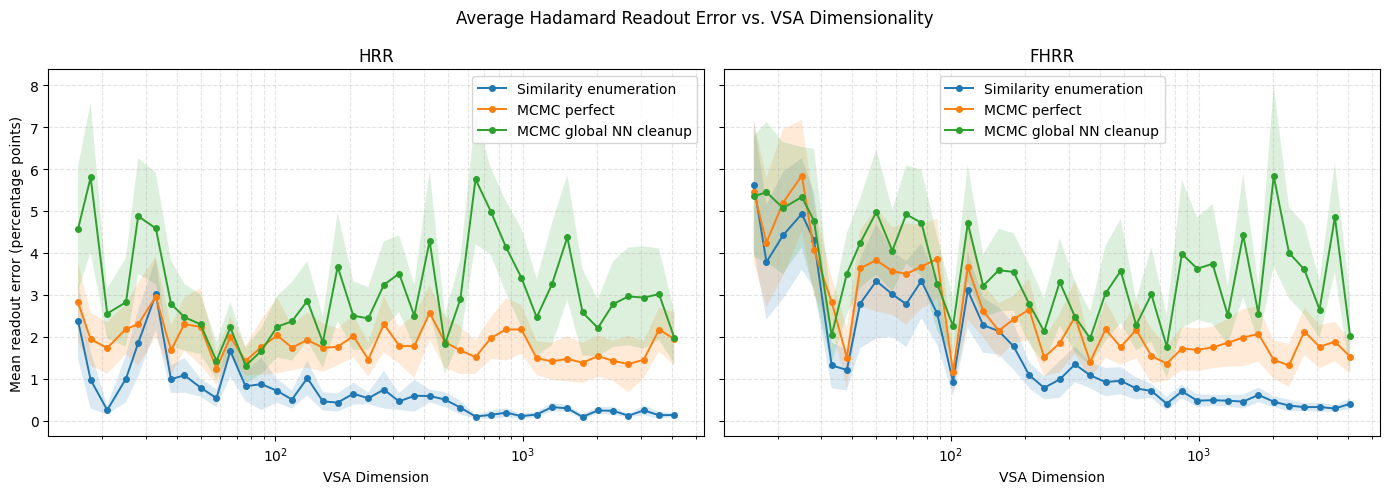

In [ ]:
# Hadamard Gate Readout Accuracy vs VSA Dimension
# The Hadamard is applied in coefficient space, then encoded back into the selected
# VSA backend. Exact enumeration and all MCMC variants use the same trials.

rng = np.random.default_rng(5)
RUN_MODE = EXPERIMENT_RUN_MODE
active_n_qubits = 1
cleanup_max_n_qubits = max(active_n_qubits, CLEANUP_DECODER_MAX_QUBITS)

if RUN_MODE == "fast":
    n_codebooks = 3
    n_trials = 8
    n_mcmc_samples = 600
    VSA_dims = log_int_space(16, 4096, 40, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_FAST
elif RUN_MODE == "experiment":
    n_codebooks = 10
    n_trials = 100
    n_mcmc_samples = 1000
    VSA_dims = log_int_space(16, 4096, 400, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_DEFAULT
else:
    raise ValueError("EXPERIMENT_RUN_MODE must be 'fast' or 'experiment'")

hadamard_summaries = {
    rep: {SIMILARITY_ENUMERATION_LABEL: [], **{label: [] for label, _method, _kind in MCMC_CLEANUP_VARIANTS}}
    for rep in REPRESENTATIONS_TO_COMPARE
}
hadamard_cleanup_stats = {rep: [] for rep in REPRESENTATIONS_TO_COMPARE}

for trial_VSA_dim in tqdm(VSA_dims, desc="Hadamard readout sweep"):
    for representation in REPRESENTATIONS_TO_COMPARE:
        errors_by_method = {label: [] for label in hadamard_summaries[representation]}

        for codebook in range(n_codebooks):
            QuantumVSAs = SymbolicEngineQuantumVSA(
                VSA_dim=int(trial_VSA_dim),
                n_qubits=cleanup_max_n_qubits,
                n_states=2,
                seed=20_000 + int(trial_VSA_dim) * 17 + codebook,
                device=EXPERIMENT_DEVICE,
                representation=representation,
            )

            amplitudes = random_normalized_qubit_states(rng, n_trials)
            output_amplitudes = single_qubit_hadamard_output_amplitudes(amplitudes)
            true_probs = true_probabilities_from_amplitudes(output_amplitudes)
            phi_prime_batch = make_states_from_amplitudes_batch(QuantumVSAs, output_amplitudes, n_qubits=active_n_qubits)
            pred_exact = readout_probabilities_exact_batch(phi_prime_batch, QuantumVSAs, n_qubits=active_n_qubits)
            errors_by_method[SIMILARITY_ENUMERATION_LABEL].extend(
                probability_errors_percentage_points(true_probs, pred_exact)
            )

            cleanup_models, cleanup_stats = get_cleanup_models_for_variants(
                QuantumVSAs,
                active_n_qubits=active_n_qubits,
                cleanup_max_n_qubits=cleanup_max_n_qubits,
                cleanup_training_config=cleanup_training_config,
                seed_base=420_000 + int(trial_VSA_dim) * 100 + codebook,
            )
            hadamard_cleanup_stats[representation].append(cleanup_stats)

            for label, cleanup_method, neural_kind in MCMC_CLEANUP_VARIANTS:
                params = selected_mcmc_kwargs_for_variant(
                    representation,
                    label,
                    cleanup_method,
                    neural_kind,
                    active_n_qubits,
                    cleanup_max_n_qubits,
                )
                pred_mcmc, _stats = readout_probabilities_mcmc_many(
                    phi_prime_batch,
                    QuantumVSAs,
                    n_qubits=active_n_qubits,
                    n_samples=n_mcmc_samples,
                    seed=200_000 + int(trial_VSA_dim) * 1000 + codebook * 100,
                    cleanup_method=cleanup_method,
                    cleanup_model=cleanup_models[label],
                    cleanup_training_config=cleanup_training_config,
                    neural_kind=neural_kind,
                    max_n_qubits=cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits),
                    **params,
                )
                errors_by_method[label].extend(probability_errors_percentage_points(true_probs, pred_mcmc))

        for label, errors in errors_by_method.items():
            hadamard_summaries[representation][label].append(summarize_error_samples(errors))

plot_representation_error_summaries(
    VSA_dims,
    hadamard_summaries,
    "Average Hadamard Readout Error vs. VSA Dimensionality",
    log_y=False,
)


## Quantum Teleportation

Compares teleportation readout error across HRR/FHRR and all cleanup variants.


Teleportation readout sweep: 100%|██████████| 32/32 [02:52<00:00,  5.41s/it]


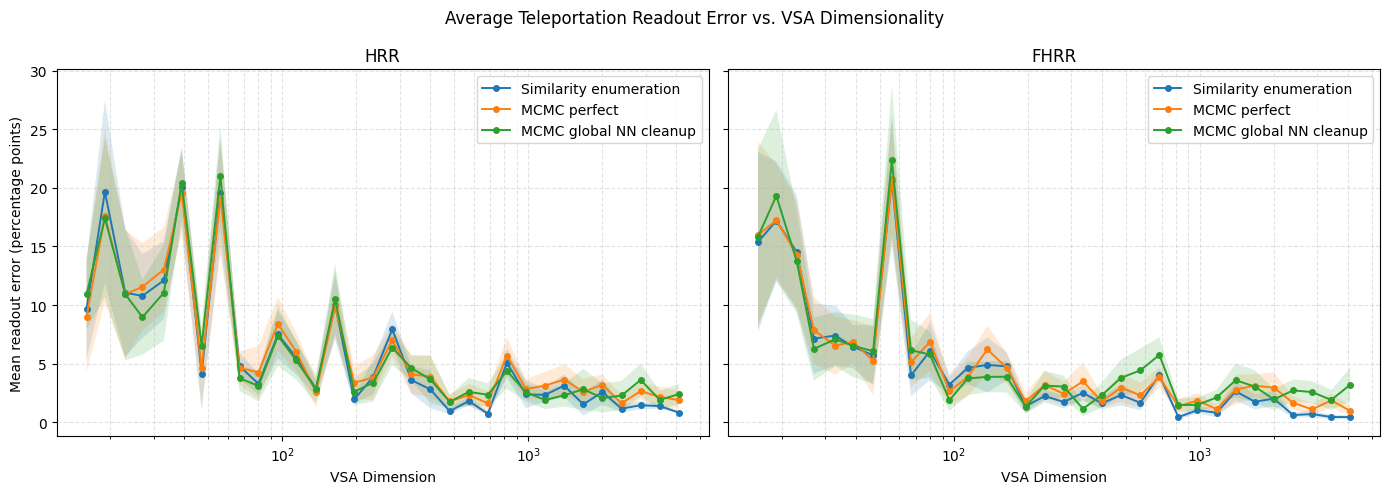

In [ ]:
# Quantum Teleportation Readout Accuracy vs VSA Dimension
# The post-Alice teleportation state is computed in coefficient space and then
# encoded into HRR or FHRR. Exact enumeration and all MCMC variants use the same trials.

rng = np.random.default_rng(6)
RUN_MODE = EXPERIMENT_RUN_MODE
active_n_qubits = 3
cleanup_max_n_qubits = max(active_n_qubits, CLEANUP_DECODER_MAX_QUBITS)

if RUN_MODE == "fast":
    n_codebooks = 2
    n_trials = 6
    n_mcmc_samples = 800
    VSA_dims = log_int_space(16, 4096, 40, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_FAST
elif RUN_MODE == "experiment":
    n_codebooks = 8
    n_trials = 125
    n_mcmc_samples = 10_000
    VSA_dims = log_int_space(16, 4096, 400, base=2.0)
    cleanup_training_config = CLEANUP_TRAINING_DEFAULT
else:
    raise ValueError("EXPERIMENT_RUN_MODE must be 'fast' or 'experiment'")

teleportation_summaries = {
    rep: {SIMILARITY_ENUMERATION_LABEL: [], **{label: [] for label, _method, _kind in MCMC_CLEANUP_VARIANTS}}
    for rep in REPRESENTATIONS_TO_COMPARE
}
teleportation_cleanup_stats = {rep: [] for rep in REPRESENTATIONS_TO_COMPARE}

for trial_VSA_dim in tqdm(VSA_dims, desc="Teleportation readout sweep"):
    for representation in REPRESENTATIONS_TO_COMPARE:
        errors_by_method = {label: [] for label in teleportation_summaries[representation]}

        for codebook in range(n_codebooks):
            QuantumVSAs = SymbolicEngineQuantumVSA(
                VSA_dim=int(trial_VSA_dim),
                n_qubits=cleanup_max_n_qubits,
                n_states=2,
                seed=30_000 + int(trial_VSA_dim) * 17 + codebook,
                device=EXPERIMENT_DEVICE,
                representation=representation,
            )

            input_amplitudes = random_normalized_qubit_states(rng, n_trials)
            true_probs = true_probabilities_from_amplitudes(input_amplitudes)
            post_alice_amplitudes = teleportation_post_alice_amplitudes(
                input_amplitudes[:, 0],
                input_amplitudes[:, 1],
            )
            phi2_batch = make_states_from_amplitudes_batch(QuantumVSAs, post_alice_amplitudes, n_qubits=active_n_qubits)
            full_probs_exact = readout_probabilities_exact_batch(phi2_batch, QuantumVSAs, n_qubits=active_n_qubits)
            pred_exact = corrected_bob_distribution_from_full_probs_batch(full_probs_exact)
            errors_by_method[SIMILARITY_ENUMERATION_LABEL].extend(
                probability_errors_percentage_points(true_probs, pred_exact)
            )

            cleanup_models, cleanup_stats = get_cleanup_models_for_variants(
                QuantumVSAs,
                active_n_qubits=active_n_qubits,
                cleanup_max_n_qubits=cleanup_max_n_qubits,
                cleanup_training_config=cleanup_training_config,
                seed_base=430_000 + int(trial_VSA_dim) * 100 + codebook,
            )
            teleportation_cleanup_stats[representation].append(cleanup_stats)

            for label, cleanup_method, neural_kind in MCMC_CLEANUP_VARIANTS:
                params = selected_mcmc_kwargs_for_variant(
                    representation,
                    label,
                    cleanup_method,
                    neural_kind,
                    active_n_qubits,
                    cleanup_max_n_qubits,
                )
                full_probs_mcmc, _stats = readout_probabilities_mcmc_many(
                    phi2_batch,
                    QuantumVSAs,
                    n_qubits=active_n_qubits,
                    n_samples=n_mcmc_samples,
                    seed=300_000 + int(trial_VSA_dim) * 1000 + codebook * 100,
                    cleanup_method=cleanup_method,
                    cleanup_model=cleanup_models[label],
                    cleanup_training_config=cleanup_training_config,
                    neural_kind=neural_kind,
                    max_n_qubits=cleanup_variant_max_n_qubits(neural_kind, active_n_qubits, cleanup_max_n_qubits),
                    **params,
                )
                pred_mcmc = corrected_bob_distribution_from_full_probs_batch(full_probs_mcmc)
                errors_by_method[label].extend(probability_errors_percentage_points(true_probs, pred_mcmc))

        for label, errors in errors_by_method.items():
            teleportation_summaries[representation][label].append(summarize_error_samples(errors))

plot_representation_error_summaries(
    VSA_dims,
    teleportation_summaries,
    "Average Teleportation Readout Error vs. VSA Dimensionality",
    log_y=False,
)


## MCMC Sampler Hyperparameter Sweep

Optional deeper sweep for gamma and variance across representation and cleanup variant.


In [ ]:
# MCMC sweep utilities
# KL, TV, and top-k helper functions are defined in the shared helper cell so the
# early calibration cell can use them before the optional full sweep below.


In [17]:
# Run MCMC hyperparameter sweep
# Optional deeper diagnostic sweep. The early calibration cell already selects the
# parameters used by the main experiments. This sweep compares all cleanup variants.

FAST_MCMC_SWEEP_MODE = False
SWEEP_REPRESENTATIONS = ("hrr", "fhrr")
SWEEP_CLEANUP_VARIANTS = MCMC_CLEANUP_VARIANTS

n_qubits = 4
cleanup_max_n_qubits = max(n_qubits, CLEANUP_DECODER_MAX_QUBITS)
VSA_dim = 2048
n_states = 2

if FAST_MCMC_SWEEP_MODE:
    n_samples = 2_000
    n_points = 25
    random_trials = 5
    xi_grid = np.array([1.0], dtype=np.float64)
    cleanup_training_config = CLEANUP_TRAINING_FAST
else:
    n_samples = 10_000
    n_points = 100
    random_trials = 5
    xi_grid = np.array([1.0], dtype=np.float64)
    cleanup_training_config = CLEANUP_TRAINING_DEFAULT

gamma_grid = np.logspace(3, -8, n_points)
variance_grid = np.logspace(3, -8, n_points)

rng = np.random.default_rng(42)
coefs = rng.random((random_trials, n_states**n_qubits))
amplitudes = coefs / np.sqrt(np.sum(np.abs(coefs) ** 2, axis=1, keepdims=True))
true_probs = true_probabilities_from_amplitudes(amplitudes)

mcmc_sweep_results = {}

for representation in SWEEP_REPRESENTATIONS:
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=VSA_dim,
        n_qubits=cleanup_max_n_qubits,
        n_states=n_states,
        seed=41,
        device=EXPERIMENT_DEVICE,
        representation=representation,
    )
    phi_batch = make_states_from_amplitudes_batch(QuantumVSAs, amplitudes, n_qubits=n_qubits)
    cleanup_models, cleanup_stats = get_cleanup_models_for_variants(
        QuantumVSAs,
        active_n_qubits=n_qubits,
        cleanup_max_n_qubits=cleanup_max_n_qubits,
        cleanup_training_config=cleanup_training_config,
        seed_base=440_000,
        verbose=True,
    )

    for label, cleanup_method, neural_kind in SWEEP_CLEANUP_VARIANTS:
        tv_scores = np.zeros((len(xi_grid), n_points, n_points), dtype=np.float64)
        kl_scores = np.zeros_like(tv_scores)
        accept_rate = np.zeros_like(tv_scores)

        pbar = tqdm(
            total=len(xi_grid) * n_points * n_points,
            desc=f"{representation.upper()} {label} sweep",
            unit="cell",
        )

        for x_idx, xi in enumerate(xi_grid):
            for i, variance in enumerate(variance_grid):
                for j, gamma in enumerate(gamma_grid):
                    predicted_probs, stats = readout_probabilities_mcmc_many(
                        phi_batch,
                        QuantumVSAs,
                        n_qubits=n_qubits,
                        n_samples=n_samples,
                        gamma=float(gamma),
                        variance=float(variance),
                        xi=float(xi),
                        seed=1_000_000 * x_idx + 10_000 * i + 100 * j,
                        cleanup_method=cleanup_method,
                        cleanup_model=cleanup_models[label],
                        cleanup_training_config=cleanup_training_config,
                        neural_kind=neural_kind,
                        max_n_qubits=cleanup_variant_max_n_qubits(neural_kind, n_qubits, cleanup_max_n_qubits),
                    )

                    tv_scores[x_idx, i, j] = np.mean(
                        0.01 * probability_errors_percentage_points(true_probs, predicted_probs)
                    )
                    kl_scores[x_idx, i, j] = mean_kl_divergence(predicted_probs, true_probs, eps=0.0)

                    total_props = np.sum(stats["accepts"] + stats["rejects"])
                    accept_rate[x_idx, i, j] = np.sum(stats["accepts"]) / total_props if total_props > 0 else np.nan

                    pbar.update(1)
                    pbar.set_postfix({
                        "xi": f"{xi:.2f}",
                        "var": f"{variance:.1e}",
                        "gam": f"{gamma:.1e}",
                        "TV": f"{tv_scores[x_idx, i, j]:.3f}",
                        "KL": f"{kl_scores[x_idx, i, j]:.3f}",
                        "acc": f"{accept_rate[x_idx, i, j]:.2f}",
                    })

        pbar.close()

        mcmc_sweep_results[(representation, label)] = {
            "cleanup_method": cleanup_method,
            "neural_kind": neural_kind,
            "tv_scores": tv_scores,
            "kl_scores": kl_scores,
            "accept_rate": accept_rate,
            "cleanup_stats": cleanup_stats[label],
        }

print("Sweep complete.")
for (representation, label), results in mcmc_sweep_results.items():
    print(f"{representation.upper()} {label} tv_scores shape:", results["tv_scores"].shape)
    print(f"{representation.upper()} {label} kl_scores shape:", results["kl_scores"].shape)
    print(f"{representation.upper()} {label} accept_rate shape:", results["accept_rate"].shape)


qubit cleanup epoch 1: val_acc=0.618, val_loss=0.6853
qubit cleanup epoch 10: val_acc=0.710, val_loss=0.5279
qubit cleanup epoch 20: val_acc=0.700, val_loss=0.6399


HRR MCMC global NN cleanup sweep: 100%|██████████| 10000/10000 [27:10:59<00:00,  9.79s/cell, xi=1.00, var=1.0e-08, gam=1.0e-08, TV=0.935, KL=3.300, acc=1.00]  


qubit cleanup epoch 1: val_acc=0.629, val_loss=0.6840
qubit cleanup epoch 10: val_acc=0.713, val_loss=0.5186
qubit cleanup epoch 20: val_acc=0.698, val_loss=0.6297


FHRR MCMC global NN cleanup sweep: 100%|██████████| 10000/10000 [22:31:19<00:00,  8.11s/cell, xi=1.00, var=1.0e-08, gam=1.0e-08, TV=0.935, KL=3.300, acc=1.00]  

Sweep complete.
HRR MCMC perfect tv_scores shape: (1, 100, 100)
HRR MCMC perfect kl_scores shape: (1, 100, 100)
HRR MCMC perfect accept_rate shape: (1, 100, 100)
HRR MCMC global NN cleanup tv_scores shape: (1, 100, 100)
HRR MCMC global NN cleanup kl_scores shape: (1, 100, 100)
HRR MCMC global NN cleanup accept_rate shape: (1, 100, 100)
FHRR MCMC perfect tv_scores shape: (1, 100, 100)
FHRR MCMC perfect kl_scores shape: (1, 100, 100)
FHRR MCMC perfect accept_rate shape: (1, 100, 100)
FHRR MCMC global NN cleanup tv_scores shape: (1, 100, 100)
FHRR MCMC global NN cleanup kl_scores shape: (1, 100, 100)
FHRR MCMC global NN cleanup accept_rate shape: (1, 100, 100)


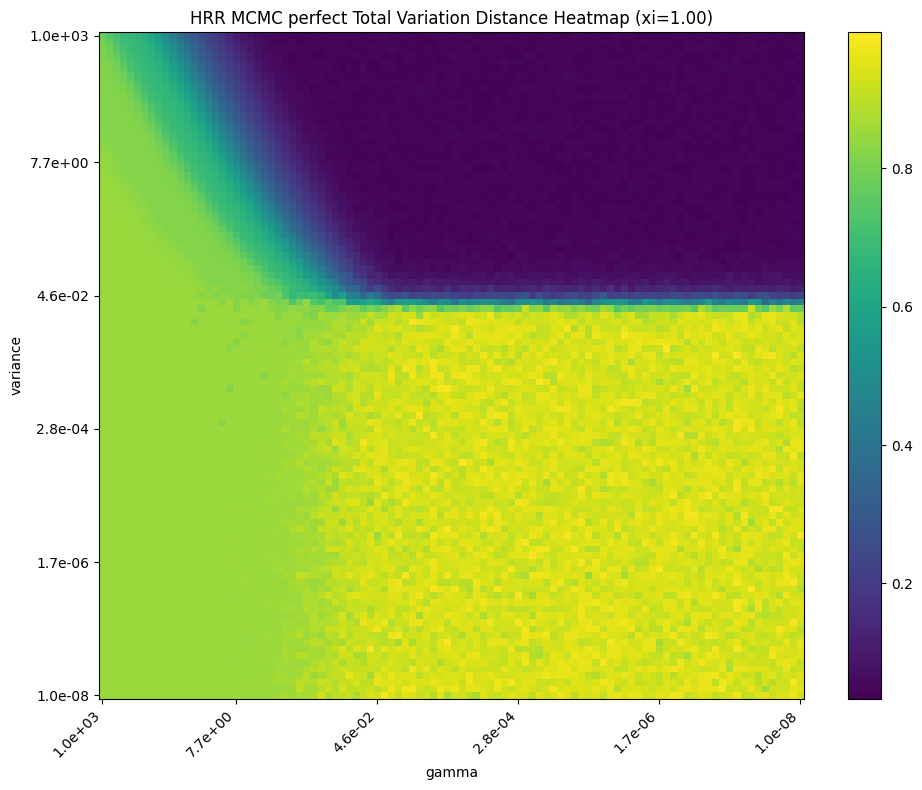

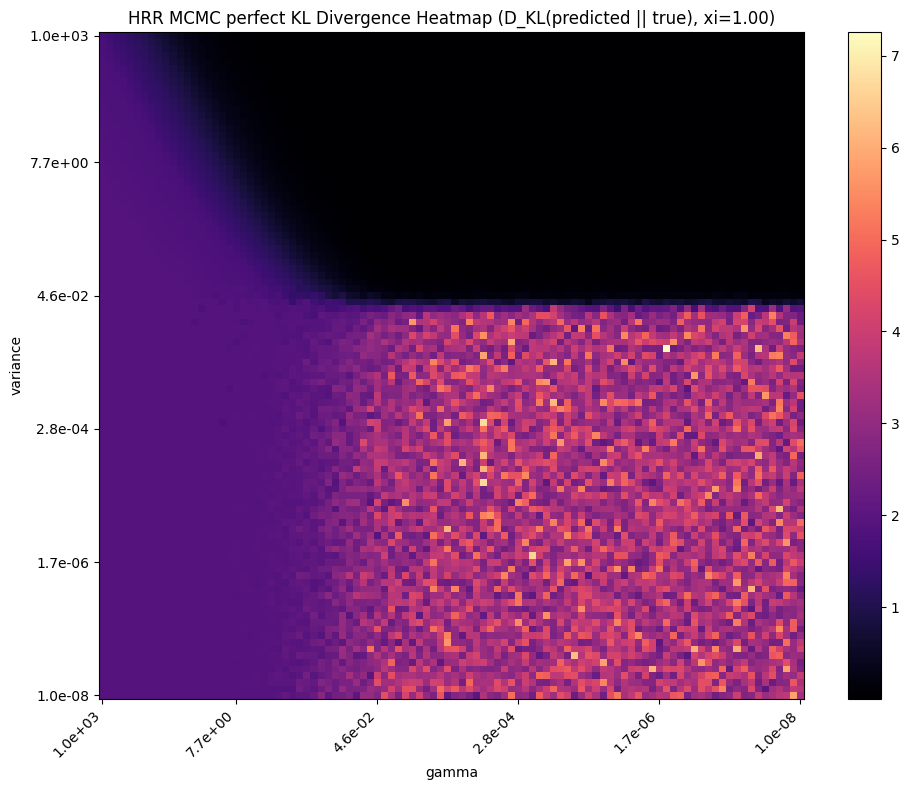

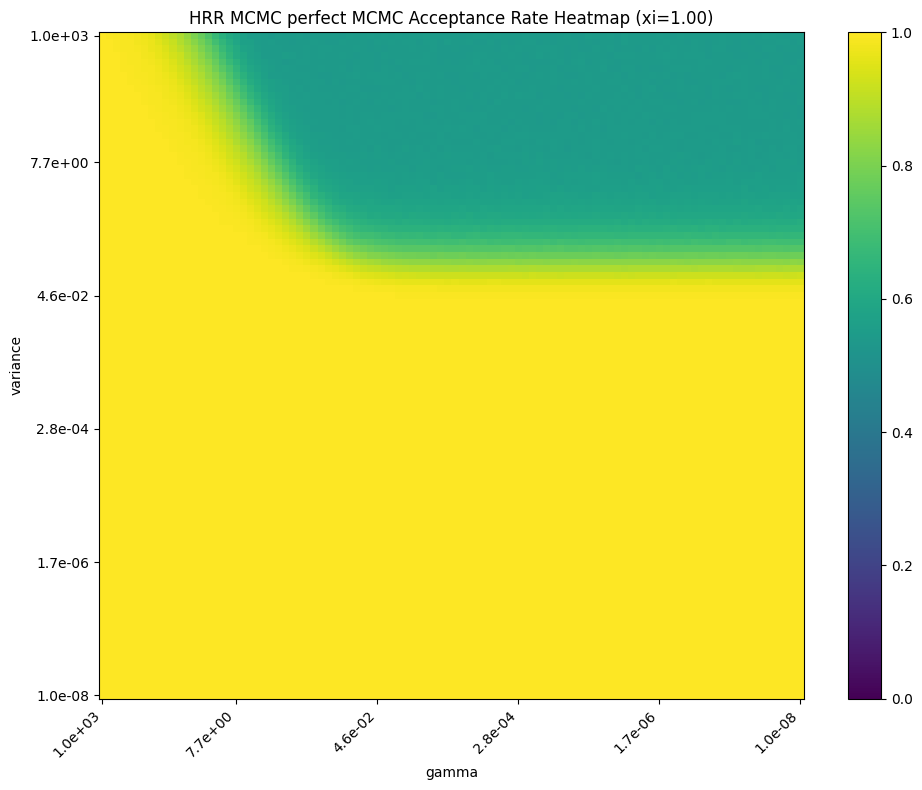

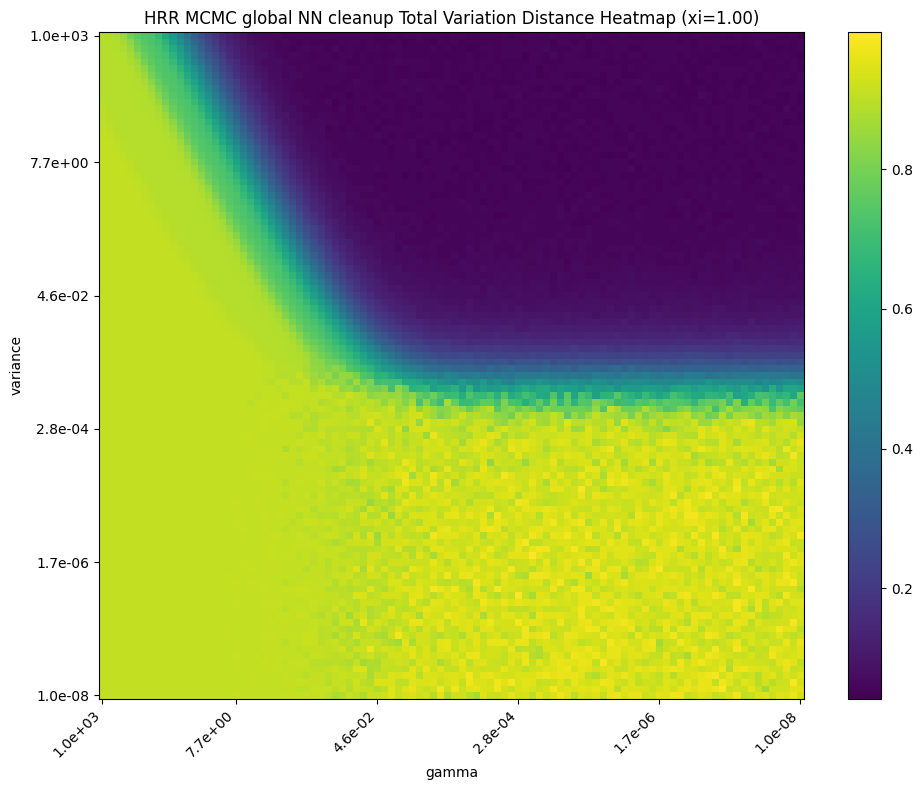

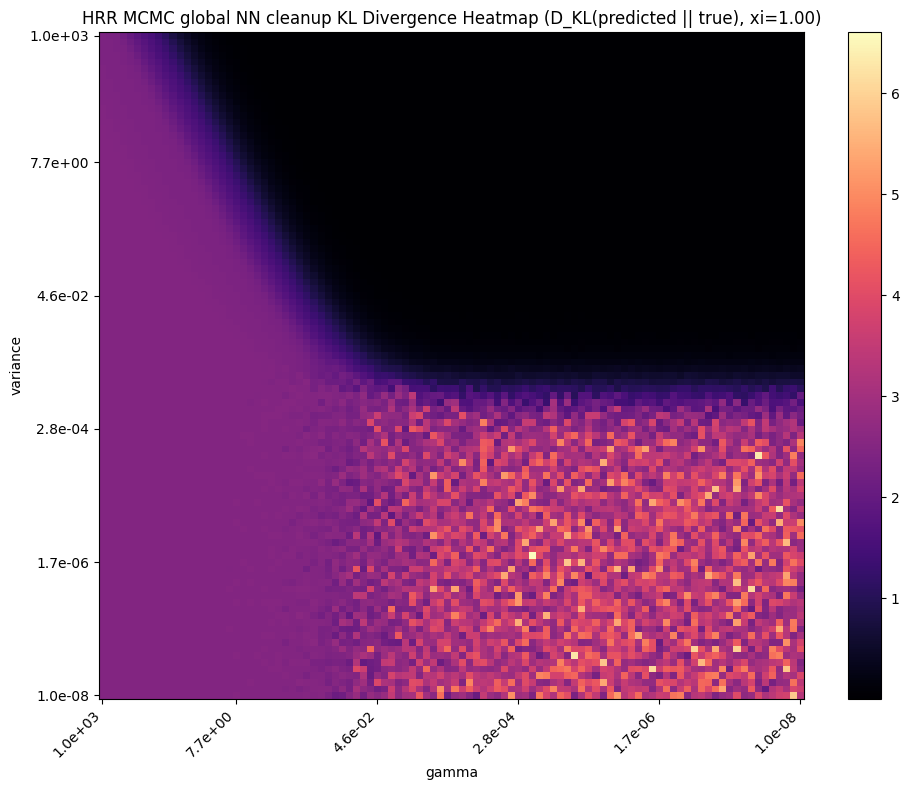

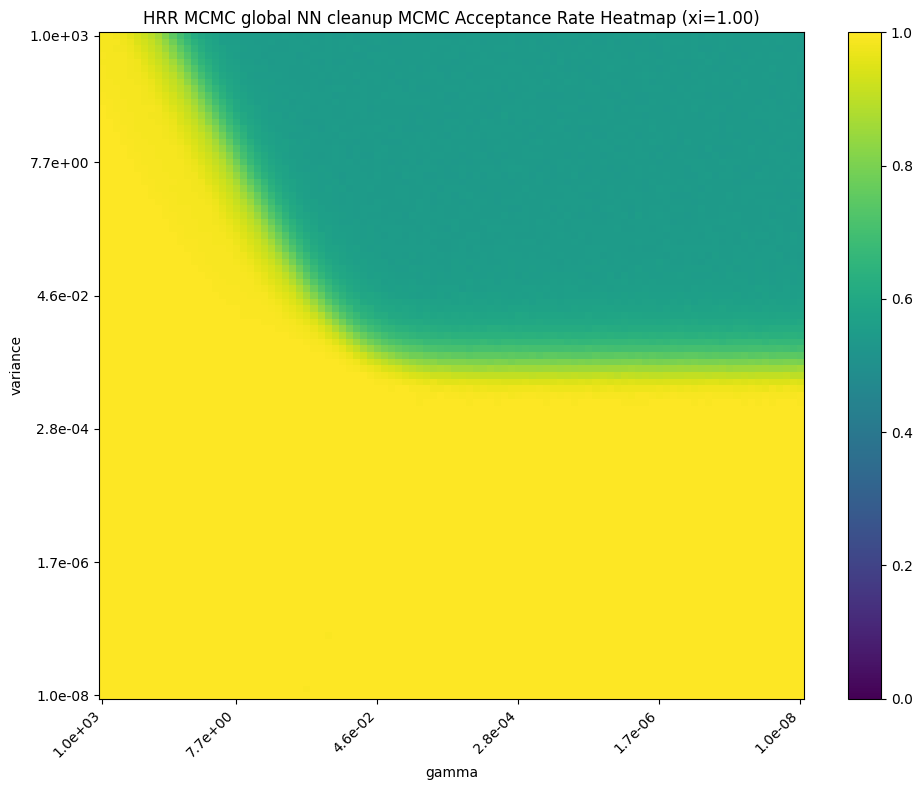

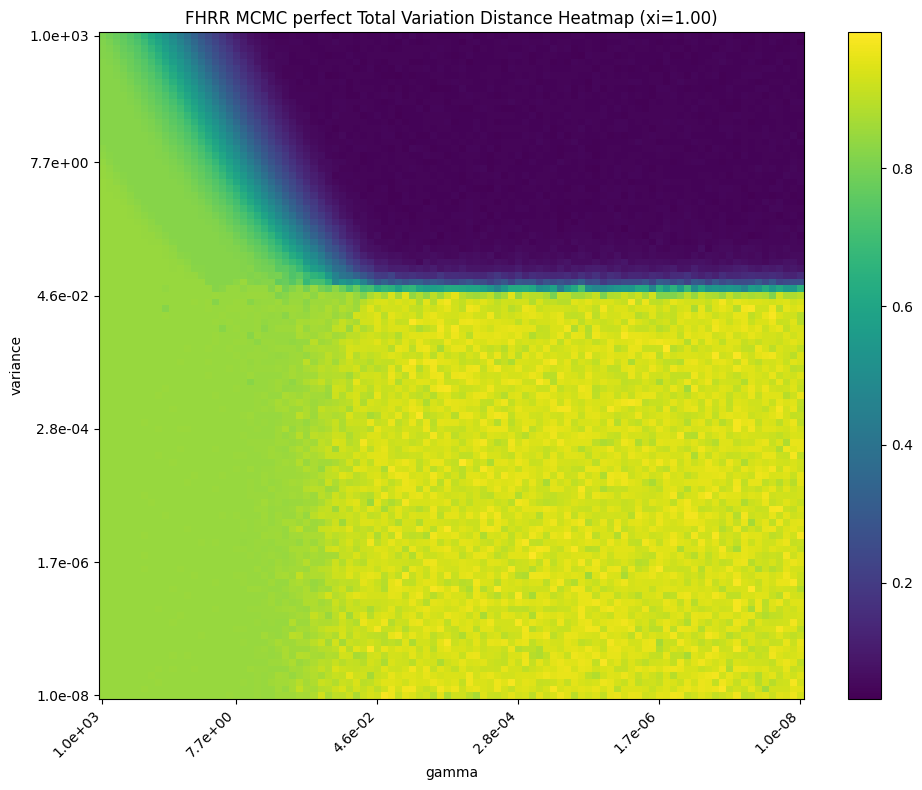

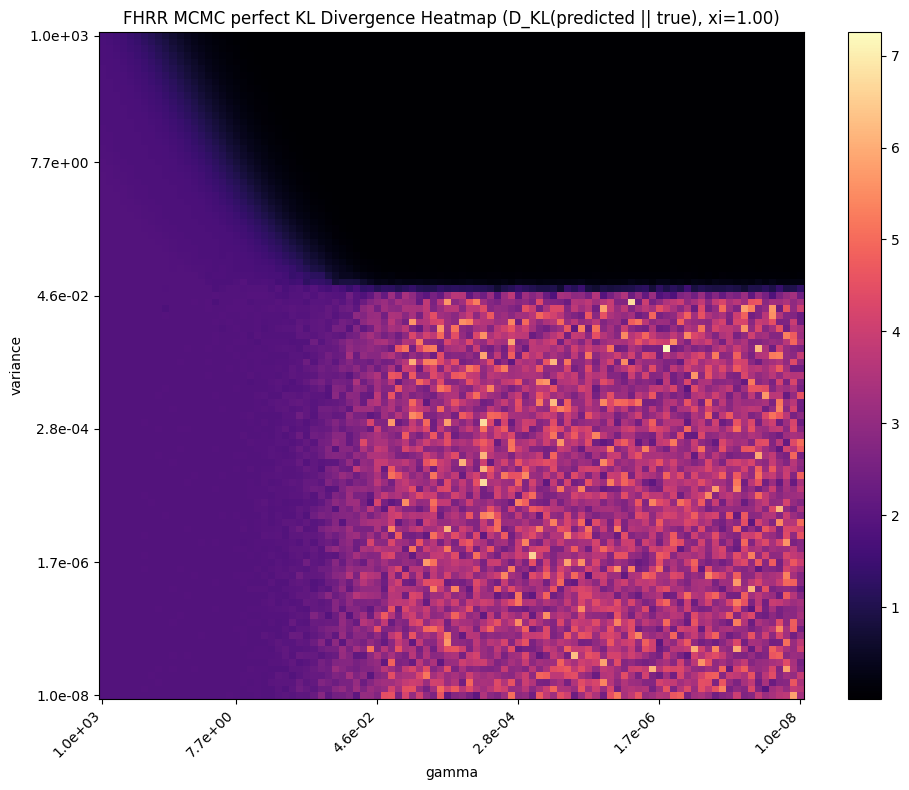

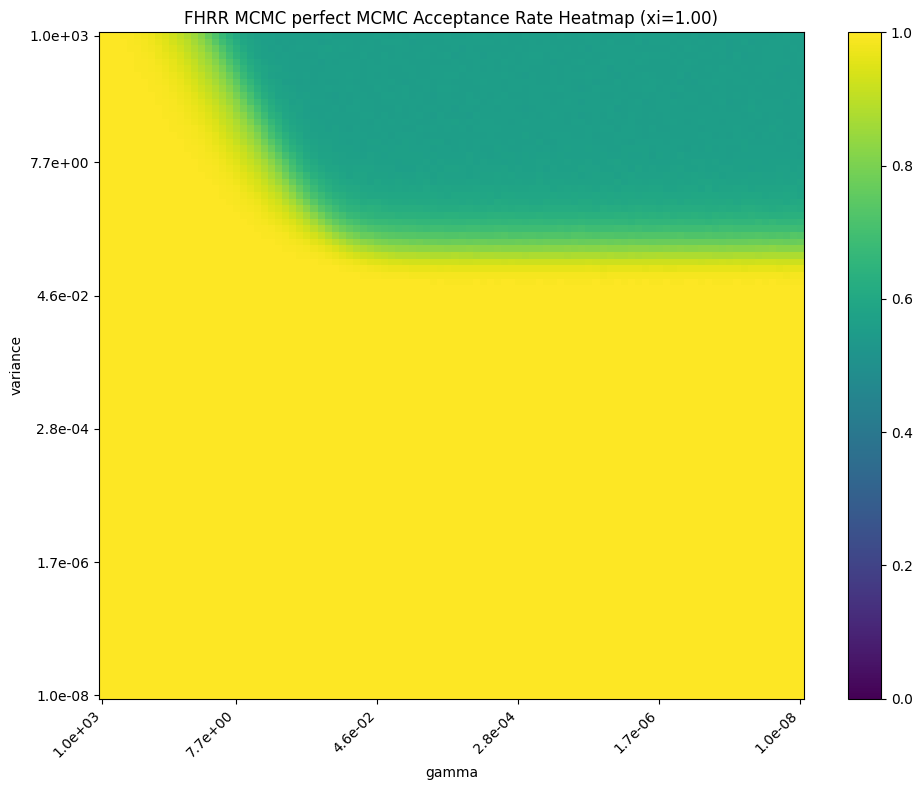

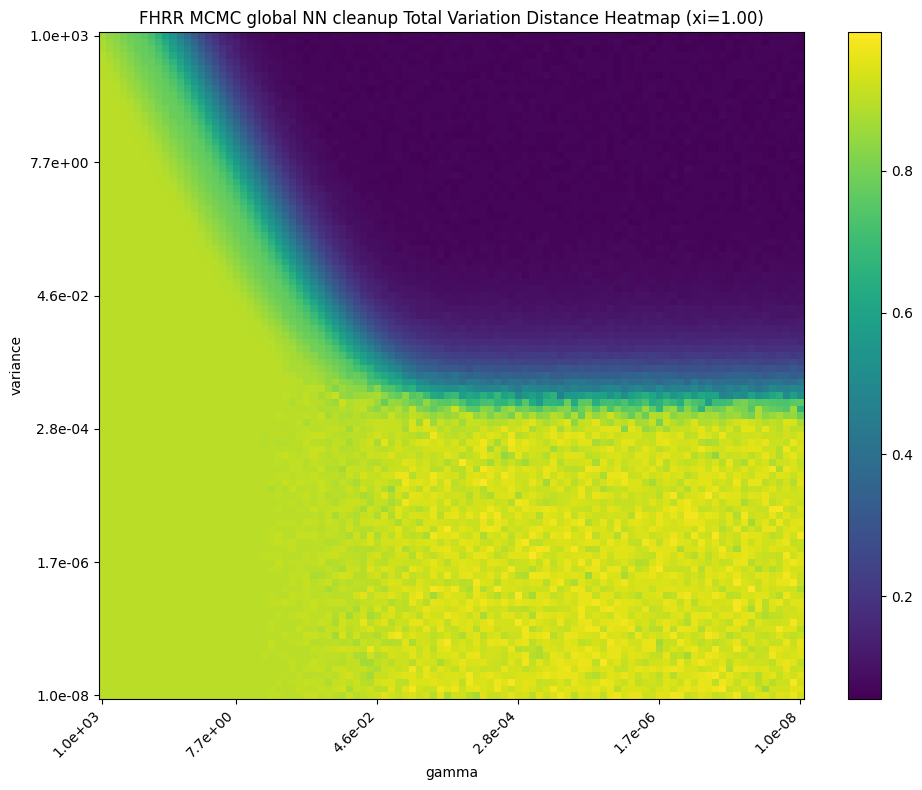

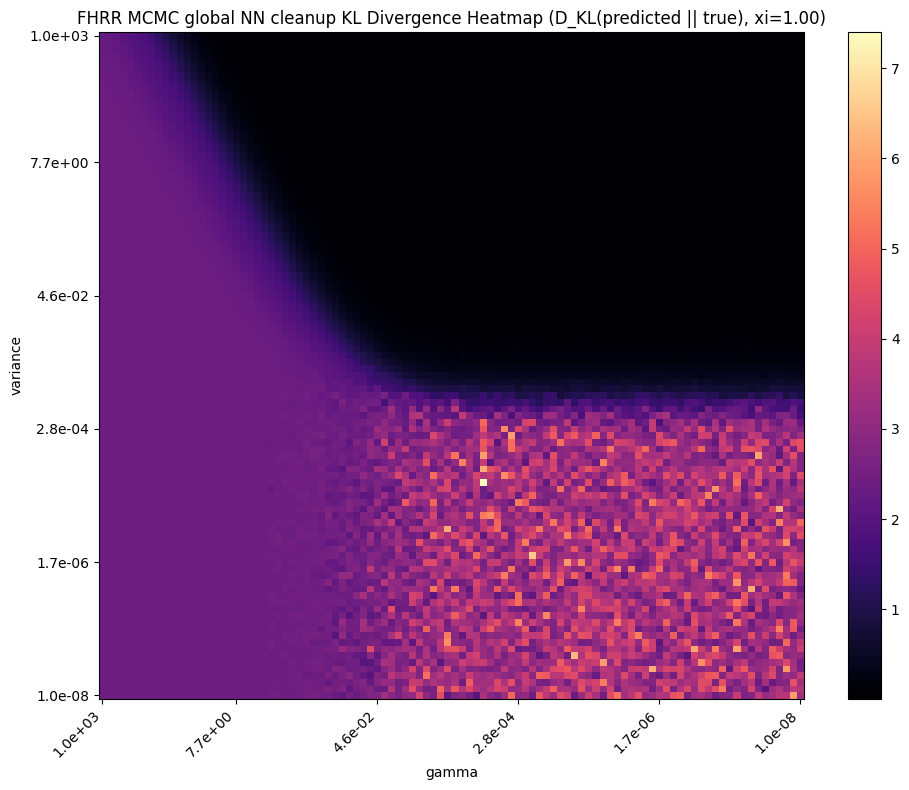

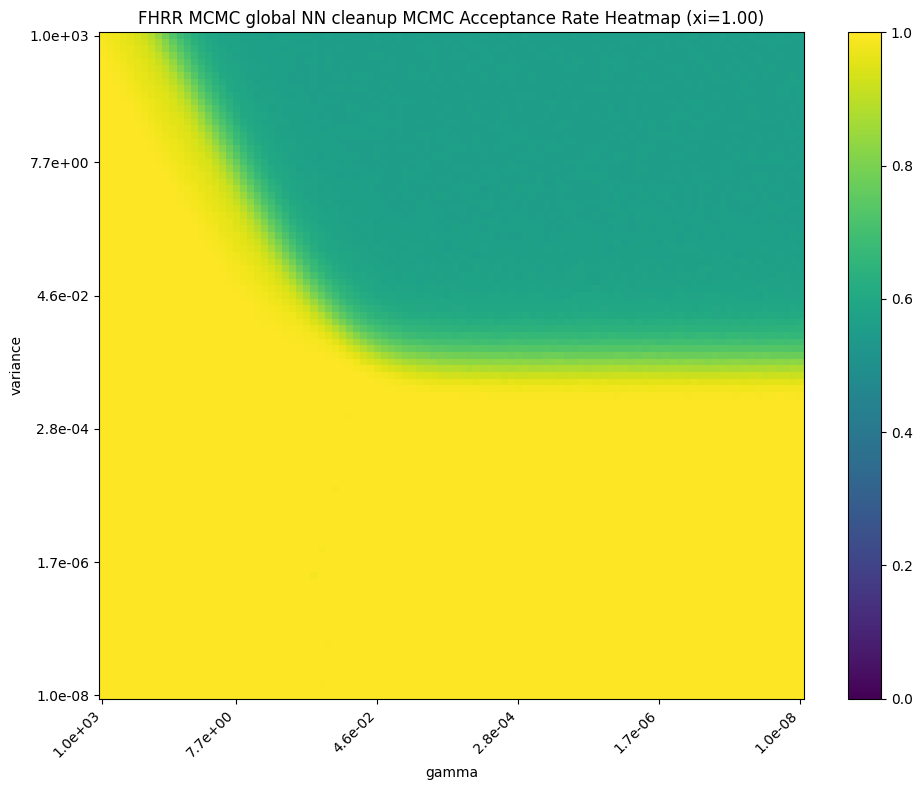

In [18]:
# Plot MCMC sweep heatmaps
# Run this after the optional full sweep cell.

tick_idx = np.linspace(0, n_points - 1, min(6, n_points), dtype=int)
tick_labels_gamma = [f"{gamma_grid[k]:.1e}" for k in tick_idx]
tick_labels_var = [f"{variance_grid[k]:.1e}" for k in tick_idx]


def plot_mcmc_heatmap(score_matrix, title, cmap, *, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(score_matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(image, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("gamma")
    ax.set_ylabel("variance")
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_labels_gamma, rotation=45, ha="right")
    ax.set_yticks(tick_idx)
    ax.set_yticklabels(tick_labels_var, rotation=0)
    plt.tight_layout()
    plt.show()


for (representation, cleanup_method), results in mcmc_sweep_results.items():
    tv_scores = results["tv_scores"]
    kl_scores = results["kl_scores"]
    accept_rate = results["accept_rate"]
    for x_idx, xi in enumerate(xi_grid):
        prefix = f"{representation.upper()} {cleanup_method}"
        plot_mcmc_heatmap(
            tv_scores[x_idx],
            f"{prefix} Total Variation Distance Heatmap (xi={xi:.2f})",
            cmap="viridis",
        )
        plot_mcmc_heatmap(
            kl_scores[x_idx],
            f"{prefix} KL Divergence Heatmap (D_KL(predicted || true), xi={xi:.2f})",
            cmap="magma",
        )
        plot_mcmc_heatmap(
            accept_rate[x_idx],
            f"{prefix} MCMC Acceptance Rate Heatmap (xi={xi:.2f})",
            cmap="viridis",
            vmin=0,
            vmax=1,
        )


In [19]:
# Inspect best MCMC hyperparameter settings from the optional full sweep

k = 10
for (representation, cleanup_method), results in mcmc_sweep_results.items():
    tv_scores = results["tv_scores"]
    kl_scores = results["kl_scores"]
    print(f"\n=== {representation.upper()} {cleanup_method} sweep results ===")
    cleanup_stats = results.get("cleanup_stats")
    if cleanup_stats is not None:
        print(
            "cleanup validation: "
            f"acc={cleanup_stats['best_val_accuracy']:.3f}, "
            f"loss={cleanup_stats['best_val_loss']:.4f}, "
            f"epochs={cleanup_stats['epochs_ran']}, "
            f"hidden_dim={cleanup_stats['hidden_dim']}"
        )

    for x_idx, xi in enumerate(xi_grid):
        print(f"\nTop combinations for xi={xi:.2f}")

        top_tv = top_k_from_score_matrix(tv_scores[x_idx], gamma_grid, variance_grid, k=k, ascending=True)
        print("Top TV combinations:")
        for r in top_tv:
            print(
                f"#{r['rank']:2d}  TV={r['score']:.6f}  "
                f"variance={r['variance']:.3e} (idx {r['variance_idx']}), "
                f"gamma={r['gamma']:.3e} (idx {r['gamma_idx']})"
            )

        top_kl = top_k_from_score_matrix(kl_scores[x_idx], gamma_grid, variance_grid, k=k, ascending=True)
        print("\nTop KL combinations:")
        for r in top_kl:
            print(
                f"#{r['rank']:2d}  KL={r['score']:.6f}  "
                f"variance={r['variance']:.3e} (idx {r['variance_idx']}), "
                f"gamma={r['gamma']:.3e} (idx {r['gamma_idx']})"
            )



=== HRR MCMC perfect sweep results ===

Top combinations for xi=1.00
Top TV combinations:
# 1  TV=0.033163  variance=1.000e+03 (idx 0), gamma=4.642e-05 (idx 66)
# 2  TV=0.034042  variance=2.783e+02 (idx 5), gamma=2.783e-04 (idx 59)
# 3  TV=0.034079  variance=5.995e+01 (idx 11), gamma=7.743e-08 (idx 91)
# 4  TV=0.034105  variance=1.000e+03 (idx 0), gamma=1.000e-02 (idx 45)
# 5  TV=0.034665  variance=5.995e+00 (idx 20), gamma=5.995e-05 (idx 65)
# 6  TV=0.035329  variance=3.594e+01 (idx 13), gamma=3.594e-06 (idx 76)
# 7  TV=0.035620  variance=5.995e+01 (idx 11), gamma=7.743e-04 (idx 55)
# 8  TV=0.035748  variance=2.154e+01 (idx 15), gamma=1.668e-06 (idx 79)
# 9  TV=0.035820  variance=1.668e+00 (idx 25), gamma=1.000e-07 (idx 90)
#10  TV=0.035946  variance=1.668e+00 (idx 25), gamma=7.743e-07 (idx 82)

Top KL combinations:
# 1  KL=0.005445  variance=1.668e+00 (idx 25), gamma=7.743e-07 (idx 82)
# 2  KL=0.005492  variance=1.000e+03 (idx 0), gamma=1.000e-02 (idx 45)
# 3  KL=0.005579  variance=

MCMC parameters: {'gamma': 1e-08, 'variance': 1.0, 'xi': 1.0}
accepts=7215, rejects=2784, state_changes=8260, TV=0.0527, KL=0.0076


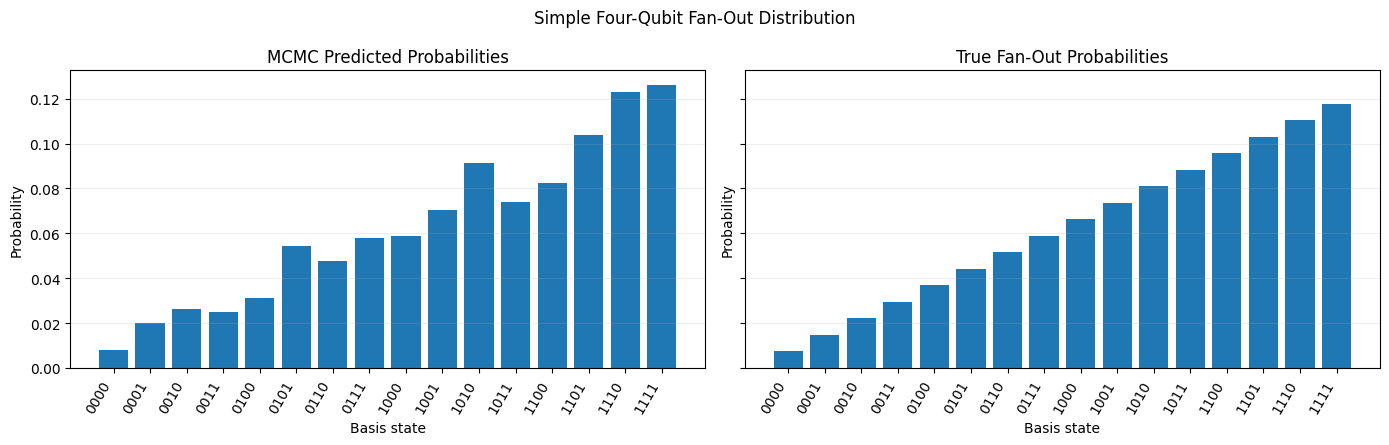

In [28]:
# Simple fan-out distribution: MCMC-predicted vs. true basis probabilities

fanout_n_qubits = 4
fanout_n_states = 2
fanout_vsa_dim = 2048
fanout_n_samples = 10_000
fanout_representation = "hrr"
fanout_cleanup_method = "perfect"

fanout_engine = SymbolicEngineQuantumVSA(
    VSA_dim=fanout_vsa_dim,
    n_qubits=fanout_n_qubits,
    n_states=fanout_n_states,
    seed=73,
    device=EXPERIMENT_DEVICE,
    representation=fanout_representation,
)

# The v3 example used weights 1, 2, ..., 16. Square-root amplitudes make
# those weights the intended linearly increasing Born probabilities.
fanout_basis_count = fanout_n_states ** fanout_n_qubits
fanout_weights = np.arange(1, fanout_basis_count + 1, dtype=np.float64)
fanout_true_probs = fanout_weights / fanout_weights.sum()
fanout_amplitudes = np.sqrt(fanout_true_probs).astype(np.complex128)
fanout_phi = make_state_from_amplitudes(
    fanout_engine,
    fanout_amplitudes,
    n_qubits=fanout_n_qubits,
)

fanout_mcmc_params = selected_mcmc_kwargs(
    fanout_representation,
    fanout_cleanup_method,
    n_qubits=fanout_n_qubits,
)
fanout_mcmc_params = {'gamma': 1e-08, 'variance': 1e0, 'xi': 1.0}

fanout_predicted_probs, fanout_stats = readout_probabilities_mcmc(
    fanout_phi,
    fanout_engine,
    n_qubits=fanout_n_qubits,
    n_samples=fanout_n_samples,
    seed=74,
    cleanup_method=fanout_cleanup_method,
    **fanout_mcmc_params,
)

fanout_tv = total_variation_distance(fanout_true_probs, fanout_predicted_probs)
fanout_kl = kl_divergence(fanout_predicted_probs, fanout_true_probs)
fanout_labels = [format(i, f"0{fanout_n_qubits}b") for i in range(fanout_basis_count)]

print("MCMC parameters:", fanout_mcmc_params)
print(
    f"accepts={fanout_stats['accepts']}, rejects={fanout_stats['rejects']}, "
    f"state_changes={fanout_stats['state_changes']}, TV={fanout_tv:.4f}, KL={fanout_kl:.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
axes[0].bar(np.arange(fanout_basis_count), fanout_predicted_probs)
axes[0].set_title("MCMC Predicted Probabilities")
axes[1].bar(np.arange(fanout_basis_count), fanout_true_probs)
axes[1].set_title("True Fan-Out Probabilities")

for ax in axes:
    ax.set_xticks(np.arange(fanout_basis_count))
    ax.set_xticklabels(fanout_labels, rotation=60, ha="right")
    ax.set_xlabel("Basis state")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Simple Four-Qubit Fan-Out Distribution")
plt.tight_layout()
plt.show()
